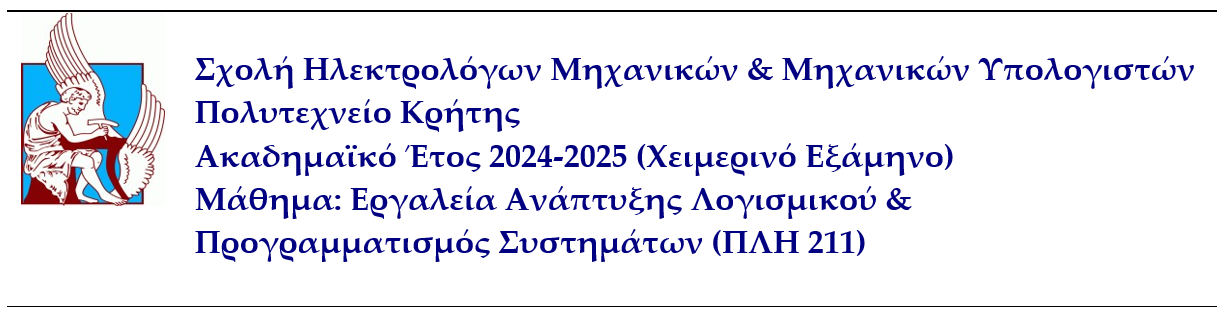

### Στοιχεία Φοιτητών Ομάδας
---
#### Φοιτητής 1
##### Όνοματεπώνυμο: **Νικολέτα Κοπάση**
##### Phases στα οποία εργάστηκε: **Development Phase, Logging Phase**
---
#### Φοιτητής 2
##### Αριθμός Μητρώου: **2020030081**
##### Όνοματεπώνυμο: **Ερμιόνη Φώτη**
##### Phases στα οποία εργάστηκε: **Profiling Phase - Μέρος 1, Refactoring Phase**
---
#### Φοιτητής 3
##### Όνοματεπώνυμο: **Ραφαήλ Γεώργιος Κοπασάκης**
##### Phases στα οποία εργάστηκε: **Profiling Phase Μέρος 2, Unit Testing Phase**
---



# Εργασία 1 - Θέμα: Aggregative Movie Preference Analyzer

---
⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰
# ΔΕΝ προχωράμε παρακάτω σε αυτό το notebook αν δεν έχουμε διαβάσει και είμαστε έτοιμοι να εφαρμόσουμε ακριβώς τις οδηγίες που διανέμονται μαζί με αυτή την εργασία στο PLH211_Project1_2024_2025_Directions.docx.
---
⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰

# Development Phase (30%)

## ⏩ Κώδικας Development Phase
Γράψτε στο παρακάτω code cell όλο τον κώδικα που υλοποιεί τον Aggregative Movie Preference Analyzer σας.

In [ ]:

def menu():
    print("=======================================================================================================")
    print("                        Hi welcome to Aggregative Movie Preference Analyzer :)                         ")
    print("=======================================================================================================")
    print("Available commands:")
    print(" 1. rating T1 T2      - Finds all the movies with mean rating grater than T1 and less or equal than T2.")
    print(" 2. top_movies K      - Finds K movies with the highest mean rating.")
    print(" 3. user_pairs K      - Finds pairs of users who have rated the same movie.")
    print(" 4. dominance         - Find movies that are not dominated by others.")
    print(" 5. iceberg K T       - Find movies with at least K reviews and an average rating above T.")
    print(" 6. top_user K        - Find the K users who have rated the most movies.")
    print(" 7. movie_sample S    - Show a sample of ~S% of the movies from each genre.")
    print(" 8. similar_users Θ   - Find users with similar tastes in movies.")
    print(" 9. exit or e         - Exit the program.")
    print("=======================================================================================================")

# Load data from a file (filename) and return it as a list of lines
def load_data(filename):
  data = []
  with open(filename, 'r') as f:
    for line in f:
      data.append(line.strip())
  return data

def mean_ratings(file):
  ratings = []
  for line in file:
    elements = line.split('::')
    ratings.append([elements[1], float(elements[2])])  # Store (movie_id, rating) as tuple

  # For each movie ID find all the ratings
  movie_ratings = {}
  for movie_id, rating in ratings:
    if movie_id not in movie_ratings:
      movie_ratings[movie_id] = []
    movie_ratings[movie_id].append(rating)

  mean_ratings = {}
  num_ratings = {}
  for movie_id, ratings in movie_ratings.items():
    mean_ratings[movie_id] = sum(ratings) / len(ratings)
    num_ratings[movie_id] = len(ratings)

  return mean_ratings, num_ratings

def find_movies_by_rating(T1, T2, file1, file2):
    movies_titles = []
    movies_rating = []
    mean_rating_dict, numof_ratings = mean_ratings(file1)

    for line in file2:
        elements = line.split('::')
        movie_id = elements[0]
        movie_title = elements[1]
        if movie_id in mean_rating_dict and T1 < mean_rating_dict[movie_id] <= T2:
            movies_titles.append(movie_title)
            movies_rating.append(mean_rating_dict[movie_id])

    return movies_titles,movies_rating

def find_top_movies(K, file1, file2):
  top_movies_titles = []
  top_movies_ratings = []

  mean_rating_dict, numof_ratings = mean_ratings(file1)
  movie_ratings = [(movie_id, rating) for movie_id, rating in mean_rating_dict.items()]

  # Sort movies by rating in descending order and take top K
  movie_ratings.sort(key=lambda item: item[1], reverse=True)
  top_movie_ids_ratings = movie_ratings[:K]

  top_movie_ids = [item[0] for item in top_movie_ids_ratings]
  movie_id_to_title = {}

  for line in file2:
    elements = line.split('::')
    movie_id = elements[0]
    movie_title = elements[1]
    movie_id_to_title[movie_id] = movie_title
    if movie_id in top_movie_ids:
        top_movies_titles.append(movie_title)
        top_movies_ratings.append(mean_rating_dict[movie_id])

  return top_movies_titles, top_movies_ratings

def find_user_pairs(K, file1, file2):
  user_pairs = []
  movie_ids = []
  user_ids = []

  for line in file1:
    elements = line.split('::')
    user_id = elements[0]
    movie_id = elements[1]
    user_ids.append(user_id)
    movie_ids.append(movie_id)

  movie_id_to_title = {}

  for line in file2:
    elements = line.split('::')
    movie_id_to_title[elements[0]] = elements[1]

  # Check the movie id in ratings file and if you find a match check if the users are different
  pair_count = 0
  for i in range(len(movie_ids)):
    for j in range(i + 1, len(movie_ids)):
      if movie_ids[i] == movie_ids[j]:
        movie_title = movie_id_to_title.get(movie_ids[i])
        if user_ids[i] != user_ids[j]:
          user_pairs.append((user_ids[i], user_ids[j], movie_title))
        pair_count += 1
        if pair_count == K:
            break
    if pair_count == K:
          break

  return user_pairs

def find_dominance(file1, file2):

    mean_rating_dict, num_ratings_dict = mean_ratings(file1)
    movie_ids = []
    movie_id_to_title = {}
    for line in file2:
        elements = line.split('::')
        movie_id = elements[0]
        if movie_id in mean_rating_dict:
            movie_ids.append(movie_id)
        movie_id_to_title[elements[0]] = elements[1]

    non_dominated = []

    for m1 in movie_ids:
        m1_dominated = False
        for m2 in movie_ids:
            if m1 != m2:
                if ((mean_rating_dict[m1] <= mean_rating_dict[m2]) and (num_ratings_dict[m1] <= num_ratings_dict[m2]) ):
                    m1_dominated = True
                    break

        if not m1_dominated:
            movie_title = movie_id_to_title[m1]
            non_dominated.append((movie_title, mean_rating_dict[m1], num_ratings_dict[m1]))

    return non_dominated

def find_iceberg(K, T, file1, file2):
    mean_rating_dict, num_ratings_dict = mean_ratings(file1)
    movie_id_to_title = {}

    for line in file2:
        elements = line.split('::')
        movie_id = elements[0]
        movie_title = elements[1]
        movie_id_to_title[movie_id] = movie_title

    results = []

    for movie_id in mean_rating_dict:
        mean_rating = mean_rating_dict[movie_id]
        num_reviews = num_ratings_dict[movie_id]

        if num_reviews >= K and mean_rating > T:
            movie_title = movie_id_to_title.get(movie_id)
            results.append((movie_title, mean_rating, num_reviews))

    return results

def find_top_users(K, file1):
  num_of_reviews = {}
  top_users = []
  for line in file1:
      elements = line.split('::')
      user_id = elements[0]
      if user_id in num_of_reviews:
          num_of_reviews[user_id] += 1
      else:
          num_of_reviews[user_id] = 1
  # Sort users by number of reviews in descending order and take top K
  sorted_users = sorted(num_of_reviews.items(), key=lambda item: item[1], reverse=True)
  top_users = sorted_users[:K]

  return top_users

def find_movie_sample(S, file2):
  genre_dict = {}

  for line in file2:
      elements = line.split('::')
      movie_id = elements[0]
      title = elements [1]
      genres = elements[2].split('|')
      for genre in genres:
        if genre not in genre_dict:
          genre_dict[genre] = []
        genre_dict[genre].append(title)

  sampled_movies = {}

  for genre, movies in genre_dict.items():
      sample_size = max(1, int(len(movies) * S / 100))
      sampled_movies[genre] = movies[:sample_size]

  return sampled_movies

def find_similar_users(theta, file1):
    user_ratings = {}
    for line in file1:
        elements = line.split('::')
        user_id = elements[0]
        movie_id = elements[1]
        rating = float(elements[2])

        if user_id not in user_ratings:
            user_ratings[user_id] = {}
        user_ratings[user_id][movie_id] = rating

    user_ids = list(user_ratings.keys())
    results = []

    for i in range(len(user_ids)):
        for j in range(i + 1, len(user_ids)):
            user1 = user_ids[i]
            user2 = user_ids[j]
            common_movies = set()
            user1_movies = set(user_ratings[user1].keys())
            user2_movies = set(user_ratings[user2].keys())
            common_movies = user1_movies.intersection(user2_movies)

            if not common_movies:
                continue

            dot_product = sum(user_ratings[user1][movie] * user_ratings[user2][movie] for movie in common_movies)
            norm_user1 = sum(user_ratings[user1][movie] ** 2 for movie in common_movies) ** 0.5
            norm_user2 = sum(user_ratings[user2][movie] ** 2 for movie in common_movies) ** 0.5

            if norm_user1 > 0 and norm_user2 > 0:
                cosine_similarity = dot_product / (norm_user1 * norm_user2)
                if cosine_similarity >= theta:
                    results.append((user1, user2, cosine_similarity))

    return results

if __name__ == "__main__":
  ratings_file = load_data('ratings.dat')
  movies_file = load_data('movies.dat')
  tag_file = load_data('tags.dat')

  i = 1;
  while i!=0:
      menu()
      command = input("\nEnter your command: ")
      args = command.split()
      print("\n")

      if args[0] == "rating":
         if len(args) != 3:
              print("Correct usage: rating T1 T2")
         else:
            try:
                T1 = float(args[1])
                T2 = float(args[2])
                if T1 > T2 or T1 > 5 or T2 > 5:
                    print("T1 must be smaller than T2 and max rating is 5.")
                    continue
                movies_titles, movies_rating = find_movies_by_rating(T1, T2, ratings_file, movies_file)
                print("{:<50} {:<10}".format("Movie Title", "Mean Rating"))
                print("_______________________________________________________________________________________________________")
                for title, rating in zip(movies_titles, movies_rating):
                    print("{:<50} {:<10.2f}".format(title, rating))
                print("\n")
            except ValueError:
                print("Correct usage: rating T1 (float) T2 (float)")

      elif args[0] == "top_movies":
          if len(args) != 2:
              print("Correct usage: top_movies K")
          elif args[1].isnumeric():
              K = int(args[1])
              movie_id_title, top_movie_ratings = find_top_movies(K,ratings_file, movies_file)
              print("{:<50} {:<10}".format("Movie Title", "Mean Rating"))
              print("_______________________________________________________________________________________________________")
              for rating, title in zip(top_movie_ratings, movie_id_title):
                      print("{:<50} {:<10.2f}".format(title, rating))
              print("\n")
          else:
              print("Correct usage: top_movies K (int)")

      elif args[0] == "user_pairs":
          if len(args) != 2:
              print("Correct usage: user_pairs K")
          elif args[1].isnumeric():
              K = int(args[1])
              user_pairs = find_user_pairs(K,ratings_file, movies_file)
              print("{:<15} {:<15} {:<30}".format("User_id", "User_id", "Movie title"))
              print("_______________________________________________________________________________________________________")
              for k in range(min(K, len(user_pairs))):
                  print("{:<15} {:<15} {:<30}".format(user_pairs[k][0], user_pairs[k][1], user_pairs[k][2]))
              print("\n")
          else:
              print("Correct usage: user_pairs K (int)")

      elif args[0] == "dominance":
          if len(args) != 1:
              print("Correct usage: dominance")
          else:
              non_dominated = find_dominance(ratings_file, movies_file)
              print("{:<50} {:<15} {:<10}".format("Movie Title", "Mean Rating", "Number of Ratings"))
              print("_______________________________________________________________________________________________________")
              for title, rating, reviews in non_dominated:
                  print("{:<50} {:<15.2f} {:<10}".format(title, rating, reviews))
              print("\n")

      elif args[0] == "iceberg":
          if len(args) != 3:
              print("Correct usage: iceberg K T")
          try:
            K = int(args[1])
            T = float(args[2])
            results = find_iceberg(K, T, ratings_file, movies_file)
            print("{:<50} {:<15} {:<10}".format("Title", "Mean Rating", "Num of Ratings"))
            print("_______________________________________________________________________________________________________")
            for title, rating, reviews in results:
                print("{:<50} {:<15.2f} {:<10}".format(title, rating, reviews))
            print("\n")
          except ValueError:
            print("Correct usage: iceberg K (int) T (float)")


      elif args[0] == "top_user":
          if len(args) != 2:
              print("Usage: top_user K")
          elif args[1].isnumeric():
              K = int(args[1])
              top_users = find_top_users(K, ratings_file)
              print("{:<10} {:<20}".format("User_id", "Number of Ratings"))
              print("_______________________________________________________________________________________________________")
              for user_id, count in top_users:
                  print("{:<1}{:<10} {:<20}".format("User:",user_id, count))
              print("\n")
          else:
              print("Correct usage: top_user K (int)")

      elif args[0] == "movie_sample":
          if len(args) != 2:
              print("Correct usage: movie_sample S")
          try:
              S = float(args[1])
              if 1 <= S <= 100:
                 sampled_movies_dict = find_movie_sample(S,movies_file)
                 print("{:<60} {:<60}".format("Genre", "Movie Title"))
                 print("_________________________________________________________________________________________")
                 for genre, movies in sampled_movies_dict.items():
                    print("{:<60} {}".format(genre, ', '.join(movies)))
              else:
                print("S must be between 1 and 100.")
          except ValueError:
              print("Correct usage: movie_sample S (float)")

      elif args[0] == "similar_users":
          if len(args) != 2:
              print("Correct usage:: similar_users Θ")
          try:
              theta = float(args[1])
              if -1 <= theta <= 1:
                  results = find_similar_users(theta, ratings_file)
                  print("{:<10} {:<10} {:<10}".format("User_id 1", "User_id 2", "\theta"))
                  print("_______________________________________________________________________________________________________")
                  for uid1, uid2, theta in results:
                      print("{:<10} {:<10} {:<10.2f}".format(uid1, uid2, theta))
                  print("\n")
              else:
                  print("Θ must be between -1 and 1.")
          except ValueError:
              print("Correct usage: similar_users Θ (float)")

      elif args[0] == "exit" or args[0] == "e":
          print("Exiting the program ok bye!")
          i = 0

      else:
          print("Invalid command. Please try again.")



                        Hi welcome to Aggregative Movie Preference Analyzer :)                         
Available commands:
 1. rating T1 T2      - Finds all the movies with mean rating grater than T1 and less or equal than T2.
 2. top_movies K      - Finds K movies with the highest mean rating.
 3. user_pairs K      - Finds pairs of users who have rated the same movie.
 4. dominance         - Find movies that are not dominated by others.
 5. iceberg K T       - Find movies with at least K reviews and an average rating above T.
 6. top_user K        - Find the K users who have rated the most movies.
 7. movie_sample S    - Show a sample of ~S% of the movies from each genre.
 8. similar_users Θ   - Find users with similar tastes in movies.
 9. exit or e         - Exit the program.

Enter your command: dominance         


Movie Title                                        Mean Rating     Number of Ratings
__________________________________________________________________________________

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## ⏩ Τεκμηρίωση και Σχολιασμός Κώδικα της Developement Phase
Γράψτε στο παρακάτω text cell αναφορά που θα περιγράφετε τι κάνει ο κώδικας που αναπτύξατε στο Development Phase στο προηγούμενο code cell (❗H τεκμηρίωση βαθμολογείται❗).

Ο κώδικας αυτός υλοποιεί μία εφαρμογή γραμμής εντολών για ανάλυση προτιμήσεων χρηστών σε ταινίες, χρησιμοποιώντας δεδομένα αξιολογήσεων από τα αρχεία που μας δώθηκαν. Η εφαρμογή δέχεται εντολές για συγκεκριμένες αναλύσεις οι οποίες αναφέρονται στο menu. Συγκεκριμένα οι συναρτήσεις έχουν ως εξής:

1. **Φόρτωση Δεδομένων (load_data)**.
Η συνάρτηση load_data διαβάζει και φορτώνει τα δεδομένα από αρχεία, ratings.dat, movies.dat, tags.dat και επιστρέφει μια λίστα με τις γραμμές του αρχείου, τις οποίες επεξεργάζονται οι άλλες συναρτήσεις.

2. **Υπολογισμός Μέσων Όρων Βαθμολογίας (mean_ratings)**.
Η mean_ratings υπολογίζει τον μέσο όρο της βαθμολογίας για κάθε ταινία και τον αριθμό των βαθμολογιών της. Επιστρέφει τις πληροφορίες σε δύο λεξικά (mean_ratings και num_ratings).

3. **Εύρεση Ταινιών σε Συγκεκριμένο εύρος Μέσων Όρων Βαθμολογιων (find_movies_by_rating)**
Η συνάρτηση find_movies_by_rating εντοπίζει ταινίες με μέσο όρο βαθμολογίας μεταξύ δύο ορίων, T1 και T2 που  δίνονται από τον χρήστη. Διατρέχει τις μέσες βαθμολογίες των ταινιών και επιστρέφει δύο λίστες με τους τίτλους και τις βαθμολογίες των ταινιών που πληρούν τα κριτήρια. (movies_titles και movies_rating)

4. **Εύρεση Κορυφαίων Ταινιών (find_top_movies)**
Στην find_top_movies, ο χρήστης καθορίζει τον αριθμό των κορυφαίων ταινιών για εκτύπωση (K) με βάση τη μέση βαθμολογία. Η συνάρτηση επιστρέφει δύο λίστες με τους τίτλους και τις βαθμολογίες των ταινιών αυτών. (top_movies_titles και top_movies_ratings)

5. **Εύρεση Κοινών Προτιμήσεων Χρηστών (find_user_pairs)**
Η find_user_pairs εντοπίζει ζευγάρια χρηστών που έχουν αξιολογήσει την ίδια ταινία. Η συνάρτηση επιστρέφει μια λίστα η οιποία περιέχει K ζεύγη χρηστών (user_id_1 and user_id_2) και την κοινή τους ταινία (movie_title). (user_pairs)

6. **Εύρεση Ταινιών που Δεν Κυριαρχούνται (find_dominance)**
Η find_dominance εντοπίζει ταινίες που δεν "κυριαρχούνται" από άλλες, δηλαδή ταινίες που έχουν υψηλότερη μέση βαθμολογία και μεγαλύτερο αριθμό κριτικών σε σύγκριση με άλλες. Επιστρέφει μια λίστα που περιέχει τον τίτλο της ταινίας την μέση βαθμολογία και τον αριθμό των κριτικών. (non_dominated)

6. **Εύρεση Ταινιών με Βάση το Πλήθος των Κριτικών και την Μέση Βαθμολογία (find_iceberg)**
Στη find_iceberg, εντοπίζονται ταινίες με τουλάχιστον K κριτικές και μέσο όρο μεγαλύτερο από T. Επιστρέφει μια λίστα με τον τίτλο τον αριθμό κριτικών και την μέση βαθμολογία των ταινιών που πληρούν τα κριτήρια. (results)

8. **Εύρεση Κορυφαίων Χρηστών (find_top_users)**
Η find_top_users εντοπίζει K χρήστες που έχουν βαθμολογήσει τις περισσότερες ταινίες. Επιστρέφει μια λίστα με το user id και τον αριθμό των κριτικών που έχει κάνει ο κάθε χρήστης. (top_users)

9. **Δείγμα Ταινιών ανά Είδος (find_movie_sample)**
Στη find_movie_sample, επιλέγεται ένα τυχαίο δείγμα από κάθε είδος ταινίας με βάση ποσοστό S που καθορίζει ο χρήστης. Επιστρέφει ένα dictionary με το είδος και τους τίτλους των τανιών. (sampled_movies)

10. **Εύρεση Χρηστών με Παρόμοιες Προτιμήσεις (find_similar_users)**
Η find_similar_users χρησιμοποιεί το Cosine Similarity μεταξύ των βαθμολογιών των χρηστών για την εύρεση χρήστες με παρόμοια γούστα στις ταινίες. Με την τιμή theta,να καθορίζεται το κατώφλι της ομοιότητας η οποία δίνεται από τον χρήστη τιμες απο [-1, 1]. Επιστρέφει μια λίστα με τα user id 1 και user id 2 και το cosine similarity τους. (results)

# Logging Phase (10%)


## ⏩ Κώδικας Logging Phase
Γράψτε στο παρακάτω code cell όλο τον κώδικα που φτιάχνει το logconfiguration.conf αρχείο με το configuration (loggers, handlers, formatters) του logger σας.

`format=%(asctime)s - %(name)s - %(levelname)s - %(message)s `

In [9]:
%%file logconfiguration.conf

[loggers]
keys=root

[handlers]
keys=fileHandler

[formatters]
keys=sampleFormatter

[logger_root]
level=INFO
handlers=fileHandler

[handler_fileHandler]
class=FileHandler
level=INFO
formatter=sampleFormatter
args=('logme.txt', 'w')

[formatter_sampleFormatter]
format=%(asctime)s - %(name)s - %(levelname)s - %(message)s


Writing logconfiguration.conf


Γράψτε στο παρακάτω code cell τον κώδικα του Aggregative Movie Preference Analyzer όπως ήταν στο Developement phase ΑΛΛΑ εδώ θα έχει και εισαγωγή των κατάλληλων εντολών που δημιουργούν τα LogRecords ώστε αυτά να γράφονται σε ένα αρχείο logme.txt .

In [13]:
import logging

logging.basicConfig(filename='logme.txt', level=logging.INFO, filemode='w')
logging.config.fileConfig('logconfiguration.conf')
logger = logging.getLogger('root')


def menu():
    print("=======================================================================================================")
    print("                        Hi welcome to Aggregative Movie Preference Analyzer :)                         ")
    print("=======================================================================================================")
    print("Available commands:")
    print(" 1. rating T1 T2      - Finds all the movies with mean rating grater than T1 and less or equal than T2.")
    print(" 2. top_movies K      - Finds K movies with the highest mean rating.")
    print(" 3. user_pairs K      - Finds pairs of users who have rated the same movie.")
    print(" 4. dominance M1 M2   - Find movies that are not dominated by others.")
    print(" 5. iceberg K T       - Find movies with at least K reviews and an average rating above T.")
    print(" 6. top_user K        - Find the K users who have rated the most movies.")
    print(" 7. movie_sample S    - Show a sample of ~S% of the movies from each genre.")
    print(" 8. similar_users Θ   - Find users with similar tastes in movies.")
    print(" 9. exit or e         - Exit the program.")
    print("=======================================================================================================")

def load_data(filename):
  data = []
  with open(filename, 'r') as f:
    for line in f:
      data.append(line.strip())
  return data

def mean_ratings(file):
  ratings = []
  for line in file:
    elements = line.split('::')
    ratings.append([elements[1], float(elements[2])])

  movie_ratings = {}
  for movie_id, rating in ratings:
    if movie_id not in movie_ratings:
      movie_ratings[movie_id] = []
    movie_ratings[movie_id].append(rating)

  mean_ratings = {}
  num_ratings = {}
  for movie_id, ratings in movie_ratings.items():
    mean_ratings[movie_id] = sum(ratings) / len(ratings)
    num_ratings[movie_id] = len(ratings)

  return mean_ratings, num_ratings

def find_movies_by_rating(T1, T2, file1, file2):
    movies_titles = []
    movies_rating = []
    mean_rating_dict, numof_ratings = mean_ratings(file1)

    for line in file2:
        elements = line.split('::')
        movie_id = elements[0]
        movie_title = elements[1]
        if movie_id in mean_rating_dict and T1 < mean_rating_dict[movie_id] <= T2:
            movies_titles.append(movie_title)
            movies_rating.append(mean_rating_dict[movie_id])

    return movies_titles,movies_rating

def find_top_movies(K, file1, file2):
  top_movies_titles = []
  top_movies_ratings = []

  mean_rating_dict, numof_ratings = mean_ratings(file1)
  movie_ratings = [(movie_id, rating) for movie_id, rating in mean_rating_dict.items()]

  movie_ratings.sort(key=lambda item: item[1], reverse=True)
  top_movie_ids_ratings = movie_ratings[:K]

  top_movie_ids = [item[0] for item in top_movie_ids_ratings]
  movie_id_to_title = {}

  for line in file2:
    elements = line.split('::')
    movie_id = elements[0]
    movie_title = elements[1]
    movie_id_to_title[movie_id] = movie_title
    if movie_id in top_movie_ids:
        top_movies_titles.append(movie_title)
        top_movies_ratings.append(mean_rating_dict[movie_id])

  return top_movies_titles, top_movies_ratings

def find_user_pairs(K, file1, file2):
  user_pairs = []
  movie_ids = []
  user_ids = []

  for line in file1:
    elements = line.split('::')
    user_id = elements[0]
    movie_id = elements[1]
    user_ids.append(user_id)
    movie_ids.append(movie_id)

  movie_id_to_title = {}

  for line in file2:
    elements = line.split('::')
    movie_id_to_title[elements[0]] = elements[1]

  pair_count = 0
  for i in range(len(movie_ids)):
    for j in range(i + 1, len(movie_ids)):
      if movie_ids[i] == movie_ids[j]:
        movie_title = movie_id_to_title.get(movie_ids[i])
        user_pairs.append((user_ids[i], user_ids[j], movie_title))
        pair_count += 1
        if pair_count == K:
            break
    if pair_count == K:
          break

  return user_pairs

def find_dominance(file1, file2):

    mean_rating_dict, num_ratings_dict = mean_ratings(file1)
    movie_ids = []
    movie_id_to_title = {}
    for line in file2:
        elements = line.split('::')
        movie_id = elements[0]
        if movie_id in mean_rating_dict:
            movie_ids.append(movie_id)
        movie_id_to_title[elements[0]] = elements[1]

    non_dominated = []

    for m1 in movie_ids:
        m1_dominated = False
        for m2 in movie_ids:
            if m1 != m2:
                if ((mean_rating_dict[m1] < mean_rating_dict[m2]) and (num_ratings_dict[m1] < num_ratings_dict[m2]) ):
                    m1_dominated = True
                    break

        if not m1_dominated:
            movie_title = movie_id_to_title[m1]
            non_dominated.append((movie_title, mean_rating_dict[m1], num_ratings_dict[m1]))

    return non_dominated

def find_iceberg(K, T, file1, file2):
    mean_rating_dict, num_ratings_dict = mean_ratings(file1)
    movie_id_to_title = {}

    for line in file2:
        elements = line.split('::')
        movie_id = elements[0]
        movie_title = elements[1]
        movie_id_to_title[movie_id] = movie_title

    results = []

    for movie_id in mean_rating_dict:
        mean_rating = mean_rating_dict[movie_id]
        num_reviews = num_ratings_dict[movie_id]

        if num_reviews >= K and mean_rating > T:
            movie_title = movie_id_to_title.get(movie_id)
            results.append((movie_title, mean_rating, num_reviews))

    return results

def find_top_users(K, file1):
  num_of_reviews = {}
  top_users = []
  for line in file1:
      elements = line.split('::')
      user_id = elements[0]
      if user_id in num_of_reviews:
          num_of_reviews[user_id] += 1
      else:
          num_of_reviews[user_id] = 1

  sorted_users = sorted(num_of_reviews.items(), key=lambda item: item[1], reverse=True)
  top_users = sorted_users[:K]

  return top_users

def find_movie_sample(S, file2):
  genre_dict = {}

  movie_id_to_title = {}

  for line in file2:
      elements = line.split('::')
      movie_id = elements[0]
      title = elements [1]
      genres = elements[2].split('|')
      for genre in genres:
        if genre not in genre_dict:
          genre_dict[genre] = []
        genre_dict[genre].append(title)

  sampled_movies = {}

  for genre, movies in genre_dict.items():
      sample_size = max(1, int(len(movies) * S / 100))
      sampled_movies[genre] = movies[:sample_size]

  return sampled_movies


def find_similar_users(theta, file1):
    user_ratings = {}
    for line in file1:
        elements = line.split('::')
        user_id = elements[0]
        movie_id = elements[1]
        rating = float(elements[2])

        if user_id not in user_ratings:
            user_ratings[user_id] = {}
        user_ratings[user_id][movie_id] = rating

    user_ids = list(user_ratings.keys())
    results = []

    for i in range(len(user_ids)):
        for j in range(i + 1, len(user_ids)):
            user1 = user_ids[i]
            user2 = user_ids[j]
            common_movies = []
            user1_movies = user_ratings[user1].keys()
            user2_movies = user_ratings[user2].keys()

            for movie in user1_movies:
                if movie in user2_movies:
                    common_movies.append(movie)
            if not common_movies:
                continue

            dot_product = sum(user_ratings[user1][movie] * user_ratings[user2][movie] for movie in common_movies)
            norm_user1 = sum(user_ratings[user1][movie] ** 2 for movie in common_movies) ** 0.5
            norm_user2 = sum(user_ratings[user2][movie] ** 2 for movie in common_movies) ** 0.5

            if norm_user1 > 0 and norm_user2 > 0:
                cosine_similarity = dot_product / (norm_user1 * norm_user2)
                if cosine_similarity >= theta:
                    results.append((user1, user2, cosine_similarity))

    return results

if __name__ == "__main__":
  logger.info("Program started.")######################
  ratings_file = load_data('ratings.dat')
  movies_file = load_data('movies.dat')
  tag_file = load_data('tags.dat')

  i = 1;
  while i!=0:
      menu()
      command = input("\nEnter your command: ")
      args = command.split()
      logger.info(f"User command: {command}")######################
      print("\n")

      if args[0] == "rating":
         if len(args) != 3:
              logger.warning(f"Warning: Wrong usage of rating.")######################
              print("Correct usage: rating T1 T2")
         else:
            try:
                T1 = float(args[1])
                T2 = float(args[2])
                if T1 > T2 or T1 > 5 or T2 > 5:
                    print("T1 must be smaller than T2 and max rating is 5.")
                    logger.warning(f"Warnign: wrong usage of rating T1 T2. T1={T1}, T2={T2} out of bounds")######################
                    continue
                logger.info(f"Executing rating with T1={T1}, T2={T2}")######################
                movies_titles, movies_rating = find_movies_by_rating(T1, T2, ratings_file, movies_file)
                print("{:<50} {:<10}".format("Movie Title", "Mean Rating"))
                print("_______________________________________________________________________________________________________")
                for title, rating in zip(movies_titles, movies_rating):
                    print("{:<50} {:<10.2f}".format(title, rating))
                print("\n")
            except ValueError:
                T1 = args[1]
                T2 = args[2]
                logger.warning(f"Warning: T1={T1}, T2={T2} is not float")######################
                print("Correct usage: rating T1 (float) T2 (float)")

      elif args[0] == "top_movies":
          if len(args) != 2:
              logger.warning(f"Warning: Wrong usage of top_movies K")######################
              print("Correct usage: top_movies K")
          elif args[1].isnumeric():
              K = int(args[1])
              logger.info(f"Executing top_movies with K={K}")######################
              movie_id_title, top_movie_ratings = find_top_movies(K,ratings_file, movies_file)
              print("{:<50} {:<10}".format("Movie Title", "Mean Rating"))
              print("_______________________________________________________________________________________________________")
              for rating, title in zip(top_movie_ratings, movie_id_title):
                      print("{:<50} {:<10.2f}".format(title, rating))
              print("\n")
          else:
              K = args[1]
              logger.warning(f"Warning: Wrong usage of top_movies K ={K} must be int")######################
              print("Correct usage: top_movies K (int)")

      elif args[0] == "user_pairs":
        if len(args) != 2:
            logger.warning(f"Warning: Wrong usage of user_pairs K")######################
            print("Correct usage: user_pairs K")
        elif args[1].isnumeric():
            K = int(args[1])
            logger.info(f"Executing user_pairs with K={K}")######################
            user_pairs = find_user_pairs(K,ratings_file, movies_file)
            print("{:<15} {:<15} {:<30}".format("User_id", "User_id", "Movie title"))
            print("_______________________________________________________________________________________________________")
            for k in range(min(K, len(user_pairs))):
                print("{:<15} {:<15} {:<30}".format(user_pairs[k][0], user_pairs[k][1], user_pairs[k][2]))
            print("\n")
        else:
            K = args[1]
            logger.warning(f"Warning: Wrong usage K= {K} must be int.")######################
            print("Correct usage: user_pairs K (int).")


      elif args[0] == "dominance":
          if len(args) != 1:
              logger.warning(f"Warning: Wrong usage of dominance")######################
              print("Usage: dominance")
          else:
              logger.info(f"Executing dominance")######################
              non_dominated = find_dominance(ratings_file, movies_file)
              print("{:<50} {:<15} {:<10}".format("Movie Title", "Mean Rating", "Number of Ratings"))
              print("_______________________________________________________________________________________________________")
              for title, rating, reviews in non_dominated:
                  print("{:<50} {:<15.2f} {:<10}".format(title, rating, reviews))
              print("\n")

      elif args[0] == "iceberg":
          if len(args) != 3:
              logger.warning(f"Warning: Wrong usage of iceberg K T")######################
              print("Correct usage: iceberg K T")
          try:
            K = int(args[1])
            T = float(args[2])
            logger.info(f"Executing iceberg with K={K} and T={T}")######################
            results = find_iceberg(K, T, ratings_file, movies_file)
            print("{:<50} {:<15} {:<10}".format("Title", "Mean Rating", "Num of Ratings"))
            print("_______________________________________________________________________________________________________")
            for title, rating, reviews in results:
                print("{:<50} {:<15.2f} {:<10}".format(title, rating, reviews))
            print("\n")
          except ValueError:
            K = args[1]
            T = args[2]
            logger.warning(f"Warning: Wrong usage of iceberg K={K}, T={T} must be int and float")######################
            print("Correct usage: iceberg K (int) T (float)")

      elif args[0] == "top_user":
          if len(args) != 2:
              logger.warning(f"Warning: Wrong usage of top_user K")######################
              print("Usage: top_user K")
          elif args[1].isnumeric():
              K = int(args[1])
              logger.info(f"Executing top_users with K={K}")######################
              top_users = find_top_users(K, ratings_file)
              print("{:<10} {:<20}".format("User_id", "Number of Ratings"))
              print("_______________________________________________________________________________________________________")
              for user_id, count in top_users:
                  print("{:<1}{:<10} {:<20}".format("User:",user_id, count))
              print("\n")
          else:
              K = args[1]
              logger.warning(f"Warning: Wrong usage of top_user K={K} must be int")######################
              print("Correct usage: top_user K (int)")

      elif args[0] == "movie_sample":
          if len(args) != 2:
              logger.warning(f"Warning: Wrong usage of movie_sample S")######################
              print("Correct usage: movie_sample S")
          try:
              S = float(args[1])
              if 1 <= S <= 100:
                 logger.info(f"Executing movie_sample with S={S}")######################
                 sampled_movies_dict = find_movie_sample(S,movies_file)
                 print("{:<60} {:<60}".format("Genre", "Movie Title"))
                 print("_________________________________________________________________________________________")
                 for genre, movies in sampled_movies_dict.items():
                    print("{:<60} {}".format(genre, ', '.join(movies)))
              else:
                logger.warning(f"Invalid S out of bounds S={S}")#
                print("S must be between 1 and 100.")
          except ValueError:
              S = args[1]
              logger.warning(f"Warning: Wrong usage of movie_sample S={S} must be float")######################
              print("Correct usage: movie_sample S (float)")

      elif args[0] == "similar_users":
          if len(args) != 2:
              print("Correct usage:: similar_users Θ")
          try:
              theta = float(args[1])
              if -1 <= theta <= 1:
                  logger.info(f"Executing similar_users with Θ={theta}")######################
                  results = find_similar_users(theta, ratings_file)
                  print("{:<10} {:<10} {:<10}".format("User_id 1", "User_id 2", "\theta"))
                  print("_______________________________________________________________________________________________________")
                  for uid1, uid2, theta in results:
                      print("{:<10} {:<10} {:<10.2f}".format(uid1, uid2, theta))
                  print("\n")
              else:
                  logger.warning(f"Invalid Θ out of bounds Θ={theta}")######################
                  print("Θ must be between -1 and 1.")
          except ValueError:
              theta = args[1]
              logger.warning(f"Warning: Wrong usage of similar_users Θ={theta} must be float")######################
              print("Correct usage: similar_users Θ (float)")

      elif args[0] == "exit" or args[0] == "e":
          logger.info("Program ended.")######################
          print("Exiting the program ok bye!")
          i = 0

      else:
          logger.warning(f"Warning: Invalid command {command}")######################
          print("Invalid command. Please try again.")


                        Hi welcome to Aggregative Movie Preference Analyzer :)                         
Available commands:
 1. rating T1 T2      - Finds all the movies with mean rating grater than T1 and less or equal than T2.
 2. top_movies K      - Finds K movies with the highest mean rating.
 3. user_pairs K      - Finds pairs of users who have rated the same movie.
 4. dominance M1 M2   - Find movies that are not dominated by others.
 5. iceberg K T       - Find movies with at least K reviews and an average rating above T.
 6. top_user K        - Find the K users who have rated the most movies.
 7. movie_sample S    - Show a sample of ~S% of the movies from each genre.
 8. similar_users Θ   - Find users with similar tastes in movies.
 9. exit or e         - Exit the program.

Enter your command: movie_sample 50


Genre                                                        Movie Title                                                 
________________________________________________

## ⏩ Τεκμηρίωση και Σχολιασμός Κώδικα της Logging Phase
Γράψτε στο παρακάτω text cell αναφορά που θα περιγράφετε τι κάνει ο κώδικας που αναπτύξατε στο Logging Phase στο προηγούμενο code cell. Σχολιάστε τη δομή του logconfiguration.conf και τη ρύθμιση των αντικειμένων που κάνατε εκεί (❗H τεκμηρίωση βαθμολογείται❗).

Το **logconfiguration.conf** αποτελέιται από τα εξής:

**[loggers]:**

Εδω καθορίζονται οι loggers που θα χρησιμοποιηθούν, συγκεκριμένα ο root ο οποίος είναι και ο default. Κάθε logger μπορεί να καταγράφει συγκεκριμένα μηνύματα ανά επίπεδο και να προωθεί τα μηνύματα σε διαφορετικούς handlers handlers. Στην προκειμένη περίπτωση το επίπεδο είναι INFO και στέλνει στον fileHandler.

**[handlers]:**

Περιλαμβάνει τους handlers που έχουν δηλωθεί, εδώ δηλαδή τον fileHandler, ο οποίος καταγράφει τα μηνύματα σε αρχείο.
Ο handler είναι υπεύθυνος για τον τρόπο με τον οποίο καταγράφονται τα μηνύματα πχ εδώ σε αρχείο.

**[formatters]:**

Δηλώνει το format των μηνυμάτων, καθορίζοντας το πώς θα κατγράφονται τα loggings.
Ο sampleFormatter διαμορφώνει τα μηνύματα με πληροφορίες όπως την ώρα καταγραφής, το όνομα του logger, το επίπεδο του μηνύματος, και το κείμενο του μηνύματος.

**[logger_root]:**

Καθορίζει το βασικό επίπεδο logging του root logger, το οποίο είναι INFO, και δηλώνει ως handler τον fileHandler.

**[handler_fileHandler]:**

Δηλώνει την κλάση FileHandler, η οποία επιτρέπει την αποθήκευση των μηνυμάτων σε αρχείο. Τα μηνύματα με επίπεδο INFO και άνω καταγράφονται στο my_logger.txt. Η παράμετρος formatter έχει οριστεί στο sampleFormatter, ώστε να καθοριστεί η δομή των μηνυμάτων.

**[formatter_sampleFormatter]:**

Χρησιμοποιείται το format που μας δώθηκε: '%(asctime)s - %(name)s - %(levelname)s - %(message)s', το οποίο προσθέτει την ώρα, το όνομα του logger, το επίπεδο και το μήνυμα, προσφέροντας καθαρή και ευανάγνωστη καταγραφή.

Στον αρχικό κώδικα, έχουν προστεθεί loggings σε διάφορα σημεία για να καταγράφουν πληροφορίες που σχετίζονται με τις ενέργειες του χρήστη, την εκτέλεση των εντολών και προειδοποιήσεις για λάθη.

# Profiling Phase - Part 1 (10%)


## ⏩ Κώδικας Profiling Phase - Part 1

Γράψτε σε ένα ή περισσότερο code cells τον κώδικα του Aggregative Movie Preference Analyzer με τις εντολές που προσθέσατε για profiling.

*Υπόδειξη: Ακολουθήστε υποχρεωτικά την ενότητα Beyond Interactive Notebooks - Profiling in IDEs της αντίστοιχης διάλεξης και το line profiler ή/και το cProfiler, memory_profiler. Προσθέστε code cells αν τα χρειάζεστε.

<h1>cProfiler<h1>

In [ ]:
import random
from collections import defaultdict

def menu():
    print("=======================================================================================================")
    print("                        Hi welcome to Aggregative Movie Preference Analyzer :)                         ")
    print("=======================================================================================================")
    print("Available commands:")
    print(" 1. rating T1 T2      - Finds all the movies with mean rating grater than T1 and less or equal than T2.")
    print(" 2. top_movies K      - Finds K movies with the highest mean rating.")
    print(" 3. user_pairs K      - Finds pairs of users who have rated the same movie.")
    print(" 4. dominance         - Find movies that are not dominated by others.")
    print(" 5. iceberg K T       - Find movies with at least K reviews and an average rating above T.")
    print(" 6. top_user K        - Find the K users who have rated the most movies.")
    print(" 7. movie_sample S    - Show a sample of ~S% of the movies from each genre.")
    print(" 8. similar_users Θ   - Find users with similar tastes in movies.")
    print(" 9. exit or e         - Exit the program.")
    print("=======================================================================================================")

def load_data(filename):
  data = []
  with open(filename, 'r') as f:
    for line in f:
      data.append(line.strip())
  return data

def load_sample_common_movies(filename, sample_size):
  data = []
  with open(filename, 'r') as f:
    for line in f:
      data.append(line.strip())

  movie_lines = defaultdict(list)
  for line in data:
    elements = line.split('::')
    movie_id = elements[1]
    movie_lines[movie_id].append(line)

  filtered_movies = {movie: lines for movie, lines in movie_lines.items() if len(lines) > 1}
  movie_ids = set(filtered_movies.keys())

  sampled_data = []

  for movie_id in movie_ids:
    sampled_data.extend(filtered_movies[movie_id])
    if len(sampled_data) >= sample_size:
      break

  sampled_data = random.sample(sampled_data, sample_size)

  return sampled_data

def mean_ratings(file):
  ratings = []
  for line in file:
    elements = line.split('::')
    ratings.append([elements[1], float(elements[2])])

  movie_ratings = {}
  for movie_id, rating in ratings:
    if movie_id not in movie_ratings:
      movie_ratings[movie_id] = []
    movie_ratings[movie_id].append(rating)

  mean_ratings = {}
  num_ratings = {}
  for movie_id, ratings in movie_ratings.items():
    mean_ratings[movie_id] = sum(ratings) / len(ratings)
    num_ratings[movie_id] = len(ratings)

  return mean_ratings, num_ratings

def find_movies_by_rating(T1, T2, file1, file2):
  movies_titles = []
  movies_rating = []
  mean_rating_dict, numof_ratings = mean_ratings(file1)

  for line in file2:
    elements = line.split('::')
    movie_id = elements[0]
    movie_title = elements[1]
    if movie_id in mean_rating_dict and T1 < mean_rating_dict[movie_id] <= T2:
      movies_titles.append(movie_title)
      movies_rating.append(mean_rating_dict[movie_id])

  return movies_titles,movies_rating

def find_top_movies(K, file1, file2):
  top_movies_titles = []
  top_movies_ratings = []

  mean_rating_dict, numof_ratings = mean_ratings(file1)
  movie_ratings = [(movie_id, rating) for movie_id, rating in mean_rating_dict.items()]

  movie_ratings.sort(key=lambda item: item[1], reverse=True)
  top_movie_ids_ratings = movie_ratings[:K]

  top_movie_ids = [item[0] for item in top_movie_ids_ratings]
  movie_id_to_title = {}

  for line in file2:
    elements = line.split('::')
    movie_id = elements[0]
    movie_title = elements[1]
    movie_id_to_title[movie_id] = movie_title
    if movie_id in top_movie_ids:
        top_movies_titles.append(movie_title)
        top_movies_ratings.append(mean_rating_dict[movie_id])

  return top_movies_titles, top_movies_ratings

def find_user_pairs(K, file1, file2):
  user_pairs = []
  movie_ids = []
  user_ids = []

  for line in file1:
    elements = line.split('::')
    user_id = elements[0]
    movie_id = elements[1]
    user_ids.append(user_id)
    movie_ids.append(movie_id)

  movie_id_to_title = {}

  for line in file2:
    elements = line.split('::')
    movie_id_to_title[elements[0]] = elements[1]

  #check the movie id in ratings file and if you find a match check if the users are different
  pair_count = 0
  for i in range(len(movie_ids)):
    for j in range(i + 1, len(movie_ids)):
      if movie_ids[i] == movie_ids[j]:
        movie_title = movie_id_to_title.get(movie_ids[i])
        if user_ids[i] != user_ids[j]:
          user_pairs.append((user_ids[i], user_ids[j], movie_title))
        pair_count += 1
        if pair_count == K:
            break
    if pair_count == K:
          break

  return user_pairs

def find_dominance(file1, file2):
  mean_rating_dict, num_ratings_dict = mean_ratings(file1)
  movie_ids = []
  movie_id_to_title = {}
  for line in file2:
    elements = line.split('::')
    movie_id = elements[0]

    if movie_id in mean_rating_dict:
      movie_ids.append(movie_id)
      movie_id_to_title[elements[0]] = elements[1]

  non_dominated = []

  for m1 in movie_ids:
    m1_dominated = False
    for m2 in movie_ids:
      if m1 != m2:
        if ((mean_rating_dict[m1] < mean_rating_dict[m2]) and (num_ratings_dict[m1] < num_ratings_dict[m2]) ):
            m1_dominated = True
            break

    if not m1_dominated:
      movie_title = movie_id_to_title[m1]
      non_dominated.append((movie_title, mean_rating_dict[m1], num_ratings_dict[m1]))

  return non_dominated

def find_iceberg(K, T, file1, file2):
  mean_rating_dict, num_ratings_dict = mean_ratings(file1)
  movie_id_to_title = {}

  for line in file2:
    elements = line.split('::')
    movie_id = elements[0]
    movie_title = elements[1]
    movie_id_to_title[movie_id] = movie_title

  results = []

  for movie_id in mean_rating_dict:
    mean_rating = mean_rating_dict[movie_id]
    num_reviews = num_ratings_dict[movie_id]

    if num_reviews >= K and mean_rating > T:
      movie_title = movie_id_to_title.get(movie_id)
      results.append((movie_title, mean_rating, num_reviews))

  return results

def find_top_users(K, file1):
  num_of_reviews = {}
  top_users = []
  for line in file1:
      elements = line.split('::')
      user_id = elements[0]
      if user_id in num_of_reviews:
          num_of_reviews[user_id] += 1
      else:
          num_of_reviews[user_id] = 1

  sorted_users = sorted(num_of_reviews.items(), key=lambda item: item[1], reverse=True)
  top_users = sorted_users[:K]

  return top_users

def find_movie_sample(S, file2):
  genre_dict = {}

  movie_id_to_title = {}

  for line in file2:
      elements = line.split('::')
      movie_id = elements[0]
      title = elements [1]
      genres = elements[2].split('|')
      for genre in genres:
        if genre not in genre_dict:
          genre_dict[genre] = []
        genre_dict[genre].append(title)

  sampled_movies = {}

  for genre, movies in genre_dict.items():
      sample_size = max(1, int(len(movies) * S / 100))
      sampled_movies[genre] = movies[:sample_size]

  return sampled_movies


def find_similar_users(theta, file1):
  user_ratings = {}
  for line in file1:
    elements = line.split('::')
    user_id = elements[0]
    movie_id = elements[1]
    rating = float(elements[2])

    if user_id not in user_ratings:
      user_ratings[user_id] = {}
      user_ratings[user_id][movie_id] = rating

  user_ids = list(user_ratings.keys())
  results = []

  for i in range(len(user_ids)):
    for j in range(i + 1, len(user_ids)):
      user1 = user_ids[i]
      user2 = user_ids[j]
      common_movies = set()
      user1_movies = set(user_ratings[user1].keys())
      user2_movies = set(user_ratings[user2].keys())
      common_movies = user1_movies.intersection(user2_movies)

      if common_movies is None:
        continue

      dot_product = sum(user_ratings[user1][movie] * user_ratings[user2][movie] for movie in common_movies)
      norm_user1 = sum(user_ratings[user1][movie] ** 2 for movie in common_movies) ** 0.5
      norm_user2 = sum(user_ratings[user2][movie] ** 2 for movie in common_movies) ** 0.5

      if norm_user1 > 0 and norm_user2 > 0:
        cosine_similarity = dot_product / (norm_user1 * norm_user2)
        if cosine_similarity >= theta:
          results.append((user1, user2, cosine_similarity))

  return results


In [ ]:
import cProfile

ratings_file = load_data('ratings.dat')
movies_file = load_data('movies.dat')
similar_users_sampled_file = load_sample_common_movies('ratings.dat',10000)

def cprofile():
  print('mean_ratings')
  cProfile.run("mean_ratings(ratings_file)")
  print('rating T1 T2')
  cProfile.run("find_movies_by_rating(0,5,ratings_file,movies_file)")
  print('top_movies K')
  cProfile.run("find_top_movies(50,ratings_file,movies_file)")
  print('user_pairs K')
  cProfile.run("find_user_pairs(30,ratings_file,movies_file)")
  print('dominance')
  cProfile.run("find_dominance(ratings_file,movies_file)")
  print('iceberg K T')
  cProfile.run("find_iceberg(150,4,ratings_file,movies_file)")
  print('top_users K')
  cProfile.run("find_top_users(100,ratings_file)")
  print('movie_sample S')
  cProfile.run("find_movie_sample(80,movies_file)")
  print('similars_users Θ')
  cProfile.run("find_similar_users(0.75,similar_users_sampled_file)")

if __name__ == '__main__':
  cprofile()


mean_ratings
         30032198 function calls in 34.797 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1   14.477   14.477   33.958   33.958 <ipython-input-25-85ee1d2b785e>:53(mean_ratings)
        1    0.838    0.838   34.796   34.796 <string>:1(<module>)
        1    0.001    0.001   34.797   34.797 {built-in method builtins.exec}
    21354    0.003    0.000    0.003    0.000 {built-in method builtins.len}
    10677    0.612    0.000    0.612    0.000 {built-in method builtins.sum}
 20000108    2.920    0.000    2.920    0.000 {method 'append' of 'list' objects}
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
        1    0.000    0.000    0.000    0.000 {method 'items' of 'dict' objects}
 10000054   15.947    0.000   15.947    0.000 {method 'split' of 'str' objects}


rating T1 T2
         4254096 function calls in 3.693 seconds

   Ordered by: standard name

   nca

KeyboardInterrupt: 

<h1>Memory_Profiler<h1>

In [ ]:
!pip install memory-profiler requests

In [ ]:
%%file mprun_demo1.py
from collections import defaultdict
import random
from memory_profiler import profile

def menu():
    print("=======================================================================================================")
    print("                        Hi welcome to Aggregative Movie Preference Analyzer :)                         ")
    print("=======================================================================================================")
    print("Available commands:")
    print(" 1. rating T1 T2      - Finds all the movies with mean rating grater than T1 and less or equal than T2.")
    print(" 2. top_movies K      - Finds K movies with the highest mean rating.")
    print(" 3. user_pairs K      - Finds pairs of users who have rated the same movie.")
    print(" 4. dominance         - Find movies that are not dominated by others.")
    print(" 5. iceberg K T       - Find movies with at least K reviews and an average rating above T.")
    print(" 6. top_user K        - Find the K users who have rated the most movies.")
    print(" 7. movie_sample S    - Show a sample of ~S% of the movies from each genre.")
    print(" 8. similar_users Θ   - Find users with similar tastes in movies.")
    print(" 9. exit or e         - Exit the program.")
    print("=======================================================================================================")

def load_data(filename):
  data = []
  with open(filename, 'r') as f:
    for line in f:
      data.append(line.strip())
  return data

def load_sample_data(filename,sample_size):
  data = []
  with open(filename, 'r') as f:
    lines = f.readlines()
  return random.sample(lines, sample_size)

def load_sample_common_movies(filename, sample_size):
  data = []
  with open(filename, 'r') as f:
    for line in f:
      data.append(line.strip())

  movie_lines = defaultdict(list)
  for line in data:
    elements = line.split('::')
    movie_id = elements[1]
    movie_lines[movie_id].append(line)

  filtered_movies = {movie: lines for movie, lines in movie_lines.items() if len(lines) > 1}

  sampled_data = []

  for lines in filtered_movies.values():
    sampled_data.extend(lines)
    if len(sampled_data) >= sample_size:
      break

  sampled_data = random.sample(sampled_data, sample_size)

  return sampled_data

@profile
def mean_ratings(file):
  ratings = []
  for line in file:
    elements = line.split('::')
    ratings.append([elements[1], float(elements[2])])

  movie_ratings = {}
  for movie_id, rating in ratings:
    if movie_id not in movie_ratings:
      movie_ratings[movie_id] = []
    movie_ratings[movie_id].append(rating)

  mean_ratings = {}
  num_ratings = {}
  for movie_id, ratings in movie_ratings.items():
    mean_ratings[movie_id] = sum(ratings) / len(ratings)
    num_ratings[movie_id] = len(ratings)

  return mean_ratings, num_ratings

@profile
def find_movies_by_rating(T1, T2, file1, file2):
  movies_titles = []
  movies_rating = []
  mean_rating_dict, numof_ratings = mean_ratings(file1)

  for line in file2:
    elements = line.split('::')
    movie_id = elements[0]
    movie_title = elements[1]
    if movie_id in mean_rating_dict and T1 < mean_rating_dict[movie_id] <= T2:
      movies_titles.append(movie_title)
      movies_rating.append(mean_rating_dict[movie_id])

  return movies_titles,movies_rating

@profile
def find_top_movies(K, file1, file2):
  top_movies_titles = []
  top_movies_ratings = []

  mean_rating_dict, numof_ratings = mean_ratings(file1)
  movie_ratings = [(movie_id, rating) for movie_id, rating in mean_rating_dict.items()]

  movie_ratings.sort(key=lambda item: item[1], reverse=True)
  top_movie_ids_ratings = movie_ratings[:K]

  top_movie_ids = [item[0] for item in top_movie_ids_ratings]
  movie_id_to_title = {}

  for line in file2:
    elements = line.split('::')
    movie_id = elements[0]
    movie_title = elements[1]
    movie_id_to_title[movie_id] = movie_title
    if movie_id in top_movie_ids:
        top_movies_titles.append(movie_title)
        top_movies_ratings.append(mean_rating_dict[movie_id])

  return top_movies_titles, top_movies_ratings

@profile
def find_user_pairs(K, file1, file2):
  user_pairs = []
  movie_ids = []
  user_ids = []

  for line in file1:
    elements = line.split('::')
    user_id = elements[0]
    movie_id = elements[1]
    user_ids.append(user_id)
    movie_ids.append(movie_id)

  movie_id_to_title = {}

  for line in file2:
    elements = line.split('::')
    movie_id_to_title[elements[0]] = elements[1]

  #check the movie id in ratings file and if you find a match check if the users are different
  pair_count = 0
  for i in range(len(movie_ids)):
    for j in range(i + 1, len(movie_ids)):
      if movie_ids[i] == movie_ids[j]:
        movie_title = movie_id_to_title.get(movie_ids[i])
        if user_ids[i] != user_ids[j]:
          user_pairs.append((user_ids[i], user_ids[j], movie_title))
        pair_count += 1
        if pair_count == K:
            break
    if pair_count == K:
          break

  return user_pairs

@profile
def find_dominance(file1, file2):
  mean_rating_dict, num_ratings_dict = mean_ratings(file1)
  movie_ids = []
  movie_id_to_title = {}
  for line in file2:
    elements = line.split('::')
    movie_id = elements[0]

    if movie_id in mean_rating_dict:
      movie_ids.append(movie_id)
      movie_id_to_title[elements[0]] = elements[1]

  non_dominated = []

  for m1 in movie_ids:
    m1_dominated = False
    for m2 in movie_ids:
      if m1 != m2:
        if ((mean_rating_dict[m1] < mean_rating_dict[m2]) and (num_ratings_dict[m1] < num_ratings_dict[m2]) ):
            m1_dominated = True
            break

    if not m1_dominated:
      movie_title = movie_id_to_title[m1]
      non_dominated.append((movie_title, mean_rating_dict[m1], num_ratings_dict[m1]))

  return non_dominated

@profile
def find_iceberg(K, T, file1, file2):
  mean_rating_dict, num_ratings_dict = mean_ratings(file1)
  movie_id_to_title = {}

  for line in file2:
    elements = line.split('::')
    movie_id = elements[0]
    movie_title = elements[1]
    movie_id_to_title[movie_id] = movie_title

  results = []

  for movie_id in mean_rating_dict:
    mean_rating = mean_rating_dict[movie_id]
    num_reviews = num_ratings_dict[movie_id]

    if num_reviews >= K and mean_rating > T:
      movie_title = movie_id_to_title.get(movie_id)
      results.append((movie_title, mean_rating, num_reviews))

  return results

@profile
def find_top_users(K, file1):
  num_of_reviews = {}
  top_users = []
  for line in file1:
      elements = line.split('::')
      user_id = elements[0]
      if user_id in num_of_reviews:
          num_of_reviews[user_id] += 1
      else:
          num_of_reviews[user_id] = 1

  sorted_users = sorted(num_of_reviews.items(), key=lambda item: item[1], reverse=True)
  top_users = sorted_users[:K]

  return top_users

@profile
def find_movie_sample(S, file2):
  genre_dict = {}

  movie_id_to_title = {}

  for line in file2:
      elements = line.split('::')
      movie_id = elements[0]
      title = elements [1]
      genres = elements[2].split('|')
      for genre in genres:
        if genre not in genre_dict:
          genre_dict[genre] = []
        genre_dict[genre].append(title)

  sampled_movies = {}

  for genre, movies in genre_dict.items():
      sample_size = max(1, int(len(movies) * S / 100))
      sampled_movies[genre] = movies[:sample_size]

  return sampled_movies

@profile
def find_similar_users(theta, file1):
  user_ratings = {}
  for line in file1:
    elements = line.split('::')
    user_id = elements[0]
    movie_id = elements[1]
    rating = float(elements[2])

    if user_id not in user_ratings:
      user_ratings[user_id] = {}
      user_ratings[user_id][movie_id] = rating

  user_ids = list(user_ratings.keys())
  results = []

  for i in range(len(user_ids)):
    for j in range(i + 1, len(user_ids)):
      user1 = user_ids[i]
      user2 = user_ids[j]
      common_movies = set()
      user1_movies = set(user_ratings[user1].keys())
      user2_movies = set(user_ratings[user2].keys())
      common_movies = user1_movies.intersection(user2_movies)

      if common_movies is None:
        continue

      dot_product = sum(user_ratings[user1][movie] * user_ratings[user2][movie] for movie in common_movies)
      norm_user1 = sum(user_ratings[user1][movie] ** 2 for movie in common_movies) ** 0.5
      norm_user2 = sum(user_ratings[user2][movie] ** 2 for movie in common_movies) ** 0.5

      if norm_user1 > 0 and norm_user2 > 0:
        cosine_similarity = dot_product / (norm_user1 * norm_user2)
        if cosine_similarity >= theta:
          results.append((user1, user2, cosine_similarity))

  return results

ratings_file = load_data('ratings.dat')
movies_file = load_data('movies.dat')
ratings_sample_file = load_sample_data('ratings.dat',10000)
user_pairs_sampled_file = load_sample_common_movies('ratings.dat',10000)
similar_users_sampled_file = load_sample_common_movies('ratings.dat',1000) #1000*1000

def movie_memory_profiler():
  print('mean_ratings')
  mean_ratings(ratings_sample_file)
  print('rating T1 T2')
  find_movies_by_rating(0, 5, ratings_file, movies_file)
  print('top_movies K')
  find_top_movies(5 , ratings_file , movies_file)
  print('user_pairs K')
  find_user_pairs (100, user_pairs_sampled_file, movies_file)
  print('dominance')
  find_dominance(ratings_file, movies_file)
  print('iceberg K T')
  find_iceberg(150, 4, ratings_file, movies_file)
  print('top_users K')
  find_top_users(100, ratings_sample_file)
  print('movie_sample S')
  find_movie_sample(80, movies_file)
  print('similars_users Θ')
  find_similar_users(0.75, similar_users_sampled_file)

if __name__ == '__main__':
  movie_memory_profiler()

Overwriting mprun_demo1.py


In [ ]:
!python -m memory_profiler mprun_demo1.py

mean_ratings
Filename: mprun_demo1.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    59   1726.4 MiB   1726.4 MiB           1   @profile
    60                                         def mean_ratings(file):
    61   1726.4 MiB      0.0 MiB           1     ratings = []
    62   1726.4 MiB      0.0 MiB       10001     for line in file:
    63   1726.4 MiB      0.0 MiB       10000       elements = line.split('::')
    64   1726.4 MiB      0.0 MiB       10000       ratings.append([elements[1], float(elements[2])])
    65                                         
    66   1726.4 MiB      0.0 MiB           1     movie_ratings = {}
    67   1726.4 MiB      0.0 MiB       10001     for movie_id, rating in ratings:
    68   1726.4 MiB      0.0 MiB       10000       if movie_id not in movie_ratings:
    69   1726.4 MiB      0.0 MiB        3012         movie_ratings[movie_id] = []
    70   1726.4 MiB      0.0 MiB       10000       movie_ratings[movie_id].append(rating)
    71  

## ⏩ Τεκμηρίωση και Σχολιασμός Κώδικα της Profiling Phase - Part 1
Γράψτε στο παρακάτω text cell αναφορά που θα περιγράφετε τι κάνει ο κώδικας που αναπτύξατε στο Profiling Phase - Part1  στα προηγούμενα code cell και **αναφέρατε τα συμπεράσματά σας για το που πρέπει να επικεντρωθεί το refactoring της επόμενης φάσης**.

<h1>CProfiler<h1>

Χρησιμοποιήσαμε το ενσωματωμένο module cProfile της Python για να αναλύσουμε τον χρόνο εκτέλεσης των συναρτήσεων μας. Το cProfile παρέχει έναν αριθμό στατιστικών στοιχείων που μας επιτρέπουν να εντοπίσουμε τυχόν σημεία του κώδικά μας που ευθύνονται για τις καθυστερήσεις στην επεξεργασία, δηλαδή τα λεγόμενα "bottlenecks". Συγκεκριμένα, τα στατιστικά που λαμβάνουμε περιλαμβάνουν:
*   ncalls: αριθμός κλήσεων για κάθε συνάρτηση
*   tottime: συνολικός χρόνος που δαπανήθηκε στην συνάρτηση
*   percall(ncalls / tottime): Μέσος χρόνος που απαιτείται για κάθε κλήση της συνάρτησης
*   cumtime: Ο συνολικός χρόνος που δαπανάται στη συνάρτηση, συμπεριλαμβανομένου όλες τις εσωτερικές κλήσεις που πραγματοποιεί.
*   percall(cumtime / ncalls): Ο μέσος χρόνος που απαιτείται για κάθε κλήση της συνάρτησης, λαμβάνοντας υπόψη όλες τις συναρτήσεις που αυτή μπορεί να καλεί.
*   filename: Αρχείο και γραμμή κώδικα στο οποίο βρίσκεται η συνάρτηση.

Εφαρμόσαμε το cProfile στις συναρτήσεις *mean_ratings*, *find_movies_by_rating*, *find_top_movies*, *find_user_pairs*, *find_dominance*, *find_iceberg*, *find_top_users*, *find_movie_sample*, και *find_similar_users*. Για τη συνάρτηση *find_similar_users*, περιορίσαμε το μέγεθος των δεδομένων σε 10.000 εγγραφές από το αρχείο
ratings.dat με τη χρήση της *load_sample_common_movies*, καθώς η επεξεργασία του πλήρους συνόλου δεδομένων ήταν ανέφικτη. Η *load_sample_common_movies* επιλέγει τυχαία δείγματα από ταινίες που έχουν αξιολογηθεί από τουλάχιστον δύο χρήστες ή διαφορετικά ότι δύο χρήστες έχουν τουλάχιστον μία κοινή βαθμολογημένη ταινία. Αυτό μας επιτρέπει να διατηρήσουμε τη σχετική σημασία των δεδομένων, διασφαλίζοντας ότι, παρά την τυχαιότητα, τα δείγματα είναι χρήσιμα για τη *find_similar_users*, η οποία βασίζεται στις κριτικές χρηστών με κοινές ταινίες για τους υπολογισμούς της.

Παρακάτω, παρατίθενται τα στιγμιότυπα από το cProfile:

<div style="text-align: center;">
    <p><strong>mean_ratings</strong></p>
    <img src="https://drive.google.com/uc?id=1JjuxOu4lALq1Xxod5n7i3njdAlO0rjVz" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_movies_by_rating</strong></p>
    <img src="https://drive.google.com/uc?id=1qfcxqriiUVT7N2ELlCg13phHUuyW_sSZ" width="500" />
</div>


<div style="text-align: center;">
    <p><strong>find_top_movies</strong></p>
    <img src="https://drive.google.com/uc?id=1fi8heHJX7CXNqSoMdKavRfT6kj3FKB9G" width="500" />
</div>


<div style="text-align: center;">
    <p><strong>find_user_pairs</strong></p>
    <img src="https://drive.google.com/uc?id=1TdysoV4S-JryVcFusN9b5nBIiOCqyOc5" width="500" />
</div>


<div style="text-align: center;">
    <p><strong>find_dominance</strong></p>
    <img src="https://drive.google.com/uc?id=1exIkP2fNSWsblBOD0V-k26gTmdL7ToZr" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_iceberg</strong></p>
    <img src="https://drive.google.com/uc?id=1GlAlq6niR2fgyRqkuoB87whaE15_Y8d5" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_top_users</strong></p>
    <img src="https://drive.google.com/uc?id=1U9j7C-6ue7DnlphPBLJ-zt9cfGkPJOXj" width="500" />
</div>


<div style="text-align: center;">
    <p><strong>find_movie_sample</strong></p>
    <img src="https://drive.google.com/uc?id=12TmEzxtIfQe9r_7xlssDidxj_c0a_CDZ" width="500" />
</div>


<div style="text-align: center;">
    <p><strong>find_similar_users</strong></p>
    <img src="https://drive.google.com/uc?id=13Hcqr4fOOioXpk_A6BVzCEQyXy9S85h5" width="500" />
</div>

Με βάση τα παραπάνω στιγμιότυπα, παρατηρήσαμε τα εξής:

*  Η συνάρτηση `mean_ratings` καλείται από τις συναρτήσεις find_dominance, find_iceberg, find_movies_by_rating, και find_top_movies, καταναλώνοντας συνολικό χρόνο (tottime) περίπου 16 δευτερολέπτων σε κάθε μία από αυτές.
*  Η μέθοδος split καλείται επανειλημμένα πάνω στα ίδια δεδομένα σε διαφορετικές συναρτήσεις καταναλώνοντας χρόνο. Ο μέγιστος συνολικός χρόνος εμφανίζεται στην συνάρτηση mean_ratings, όπου το (tottime) ανέρχεται στα 18 δευτερόλεπτα.
*  Η συνάρτηση `find_similar_users` είναι το σημείο της κύριας καθυστέρησης με χρόνο εκτέλεσης 208 δευτερολέπτων, κυρίως λόγω των υπερβολικών κλήσεων σε μεθόδους όπως keys των λεξικών (πάνω από 62 εκατομμύρια κλήσεις), sum (περίπου 39,6 δευτερόλεπτα συνολικός χρόνος) και intersection (6,8 δευτερόλεπτα).



<h1>Memory_Profiler<h1>

Χρησιμοποιήσαμε το module memory_profiler της python για να εξετάσουμε την κατανάλωση μνήμης των συναρτήσεών μας. Το memory_profiler μας επιτρέπει να παρακολουθήσουμε την μνήμη που χρησιμοποιείται σε κάθε βήμα. Μετά την εκτέλεση τα ορίσματα που επιστρέφει είναι τα εξής:
*   Line #: Ο αριθμός της γραμμής στον κώδικα, όπου καταγράφεται η κατανάλωση μνήμης.
*   Mem usage: Η συνολική κατανάλωση μνήμης μετά την εκτέλεση της συγκεκριμένης γραμμής.
*   Increment:  Η διαφορά στην κατανάλωση μνήμης από τη συγκεκριμένη γραμμή σε σχέση με την προηγούμενη.
*   Occurences: Ο αριθμός των φορών που εκτελείται μια συγκεκριμένη γραμμή του κώδικα κατά τη διάρκεια της ανάλυσης.
*   Line Contents: Ο κώδικας Python στην εκάστοτε γραμμή.

Eφαρμόσαμε memory_profiler σε κάθε μία από τις ακόλουθες συναρτήσεις *mean_ratings*, *find_movies_by_rating*, *find_top_movies*, *find_user_pairs*,  *find_dominance*, *find_iceberg*, *find_top_users*, *find_movie_sample* και *find_similar_users*.

Για τις συναρτήσεις *find_movies_by_rating*, *find_top_movies*,*find_dominance*, *find_iceberg*, *find_movie_sample* χρησιμοποιήσαμε τον συνολικό αριθμό δεδομένων των αρχείων.

Για τις συναρτήσεις *find_top_users* και *mean_ratings* επιλέξαμε τυχαία μέσω της *load_sample_data* 10000 δείγματα από τα συνολικά δεδομένα ratings.dat.

Για τις συναρτήσεις *find_user_pairs* και *find_similar_users*, χρησιμοποιήσαμε τη συνάρτηση *load_sample_common_movies* με 10.000 και 1000 δείγματα αντίστοιχα. Αυτή η συνάρτηση εξασφαλίζει ότι οι ταινίες που επιλέγονται έχουν βαθμολογηθεί από τουλάχιστον δύο διαφορετικούς χρήστες, κάτι που είναι απαραίτητο για να επιστρέψουν αποτελέσματα οι συναρτήσεις αυτές.

Η επιλογή ενός μέρους από τα δεδομένα έγινε καθώς η εφαρμογή memory_profiler στον συνολικό όγκο δεδομένων καθιστούσε αδύνατη την εκτέλεση σε ορισμένες συναρτήσεις.

Παρακάτω, παρατίθενται τα στιγμιότυπα από το memory_profiler:

<div style="text-align: center;">
    <p><strong>mean_ratings</strong></p>
    <img src="https://drive.google.com/uc?id=1YPAa0c4Cy0SSnQVGuqtyItwrbfPGJRw1" width="500" />
</div>


<div style="text-align: center;">
    <p><strong>find_movies_by_rating</strong></p>
    <img src="https://drive.google.com/uc?id=1ZloKxWMJqZfBatm-K3rODoqYjw40UqU9" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_top_movies</strong></p>
    <img src="https://drive.google.com/uc?id=1MpJXoMBK6AIlFfj_xFSwtcMOh6psP_76" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_user_pairs</strong></p>
    <img src="https://drive.google.com/uc?id=1_CnqGXIG-OKeQTKVCqiuLuwxZwtp9MeA" width="500" />
</div>


<div style="text-align: center;">
    <p><strong>find_iceberg</strong></p>
    <img src="https://drive.google.com/uc?id=1ziYQ-UVoldJFR--5XjG66R5KHitIlBe4" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_top_users</strong></p>
    <img src="https://drive.google.com/uc?id=19Eegy43rLVSv8MrT7wPxUBRvuroRYAE_" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_movie_sample</strong></p>
    <img src="https://drive.google.com/uc?id=17MeCb7O00xKXtnfhbLi4sdo_6482Bl8u" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_similar_users</strong></p>
    <img src="https://drive.google.com/uc?id=1ygiwY_2dV9PzZY86gc1Q5nmv3TeFL0L6" width="500" />
</div>

Τα αποτελέσματα που προέκυψαν είναι τα εξής:
* Υψηλή μνήμη (1666 Mib) παρατηρείται στην συνάρτηση `find_similar_users`. Αυτό είναι αναμενομένο καθώς αποθηκεύει λίστες user_ids, movie_ids καθώς και λεξικό με τις αξιολογήσεις χρηστών. Επιπλέον, αποθηκεύει όλες τις κοινές ταινίες για κάθε ζευγάρι χρηστών.
* Η υψηλότερη κατανάλωση μνήμης(1716 Mib) παρατηρείται στην συνάρτηση `find_user_pairs`, η οποία αποθηκέυει λεξικό με τους τίτλους ταινιών, καθώς και τις ταινίες για κάθε ζεύγος χρηστών.
* Στις συναρτήσεις  `find_movies_by_rating`,`find_top_movies`,`find_iceberg` και `find_dominance` η μνήμη αυξάνεται περίπου 650 Mib στο σημείο που αποθηκέυονται τα λεξικά για τους μέσους όρους και τον συνολικό αριθμό των κριτικών για κάθε ταινία.
* Η δεύτερη υψηλότερη κατανάλωση μνήμης εμφανίζεται στην συνάρτηση `mean_ratings`, η οποία αποθηκεύει σε λίστα το σύνολο των ratings για κάθε ταινία.



# Refactoring Phase (20%)

## ⏩ Κώδικας Refactoring Phase

Γράψτε στο παρακάτω code cell όλο τον κώδικα του Aggregative Movie Preference Analyzer σας αλλαγμένο (refactored) με βάση τα bottlenecks που εντοπίσατε στο profiling και διορθώσατε στο refactoring, καθώς και με βάση τις αρχές της Idomatic Python.

In [ ]:
from collections import defaultdict
import statistics as stats
import json

CACHE_FILE = 'ratings_cache.json'

def menu():
    print("=======================================================================================================")
    print("                        Hi welcome to Aggregative Movie Preference Analyzer :)                         ")
    print("=======================================================================================================")
    print("Available commands:")
    print(" 1. rating T1 T2      - Finds all the movies with mean rating grater than T1 and less or equal than T2.")
    print(" 2. top_movies K      - Finds K movies with the highest mean rating.")
    print(" 3. user_pairs K      - Finds pairs of users who have rated the same movie.")
    print(" 4. dominance         - Find movies that are not dominated by others.")
    print(" 5. iceberg K T       - Find movies with at least K reviews and an average rating above T.")
    print(" 6. top_user K        - Find the K users who have rated the most movies.")
    print(" 7. movie_sample S    - Show a sample of ~S% of the movies from each genre.")
    print(" 8. similar_users Θ   - Find users with similar tastes in movies.")
    print(" 9. exit or e         - Exit the program.")
    print("=======================================================================================================")

def load_data(filename, delimiter, fields):
  data = []
  with open(filename, 'r') as f:
    for line in f:
      elements = line.strip().split(delimiter)
      entry = {field: elements[i] for i, field in enumerate(fields)}
      data.append(entry)
  return data

def load_filtered_movies(ratings_data):

  movie_users = defaultdict(list)

  for entry in ratings_data:
    movie_users[entry['movie_id']].append(entry['user_id'])

  filtered_movie_ids = {movie for movie, users in movie_users.items() if len(users) > 1}

  filtered_data = [
        entry for entry in ratings_data if entry['movie_id'] in filtered_movie_ids
    ]
  return filtered_data

def load_cache():
  try:
    with open(CACHE_FILE, 'r') as cache_file:
      return json.load(cache_file)
  except:
      return None

def save_cache(mean_ratings, num_ratings):
  cache_data = {
    'mean_ratings': mean_ratings,
    'num_ratings': num_ratings,
  }
  with open(CACHE_FILE, 'w') as cache_file:
    json.dump(cache_data, cache_file)

def mean_ratings(ratings_data):
  cache = load_cache()

  if cache:
    mean_ratings = cache.get('mean_ratings', {})
    num_ratings= cache.get('num_ratings', {})
    return mean_ratings, num_ratings
  else:
    mean_ratings = defaultdict(float)
    num_ratings = defaultdict(int)

  for entry in ratings_data:
    movie_id = entry['movie_id']
    rating = float(entry['rating'])

    mean_ratings[movie_id] += rating
    num_ratings[movie_id] += 1

  for movie_id in mean_ratings:
    mean_ratings[movie_id] /= num_ratings[movie_id]

  save_cache(mean_ratings, num_ratings)

  return mean_ratings, num_ratings

def find_movies_by_rating(T1, T2, ratings_data, movies_data):
  movies_titles = []
  movies_rating = []
  mean_rating_dict, numof_ratings = mean_ratings(ratings_data)

  for entry in movies_data:
    movie_id = entry['movie_id']
    movie_title = entry['title']
    if movie_id in mean_rating_dict and T1 < mean_rating_dict[movie_id] <= T2:
      movies_titles.append(movie_title)
      movies_rating.append(mean_rating_dict[movie_id])

  return movies_titles,movies_rating

def find_top_movies(K, ratings_data, movies_data):

  mean_rating_dict, numof_ratings = mean_ratings(ratings_data)
  movie_ratings = [(movie_id, rating) for movie_id, rating in mean_rating_dict.items()]
  movie_ratings.sort(key=lambda item: item[1], reverse=True)

  top_movie_ids_ratings = movie_ratings[:K]
  top_movie_ids = [item[0] for item in top_movie_ids_ratings]
  movie_id_to_title = {entry['movie_id']: entry['title'] for entry in movies_data}

  top_movies_titles = [movie_id_to_title[movie_id] for movie_id in top_movie_ids]
  top_movies_ratings = [mean_rating_dict[movie_id] for movie_id in top_movie_ids]

  return top_movies_titles, top_movies_ratings

def find_user_pairs(K, ratings_data, movies_data):
  user_pairs = []
  movie_ids = []
  user_ids = []

  filtered_ratings_data = load_filtered_movies(ratings_data)
  for entry in filtered_ratings_data:
    user_id = entry['user_id']
    movie_id = entry['movie_id']
    user_ids.append(user_id)
    movie_ids.append(movie_id)

  movie_id_to_title = {}

  for entry in movies_data:
    movie_id_to_title[entry['movie_id']] = entry['title']

  pair_count = 0
  for i,movie_id1 in enumerate(movie_ids):
    for j,movie_id2 in enumerate(movie_ids[i+1:],i+1):
      if movie_id1 == movie_id2:
        movie_title = movie_id_to_title.get(movie_id1)
        if user_ids[i] != user_ids[j]:
          user_pairs.append((user_ids[i], user_ids[j], movie_title))
        pair_count += 1
        if pair_count == K:
            break
    if pair_count == K:
          break

  return user_pairs

def find_dominance(ratings_data, movies_data):

  mean_rating_dict, num_ratings_dict = mean_ratings(ratings_data)

  movie_id_to_title = {entry['movie_id']: entry['title'] for entry in movies_data}
  movie_ids = [movie_id for movie_id in mean_rating_dict]

  non_dominated = []

  non_dominated = [
    (movie_id_to_title[m1], mean_rating_dict[m1], num_ratings_dict[m1])
    for m1 in movie_ids
    if not any(
      m1 != m2 and
      mean_rating_dict[m1] <= mean_rating_dict[m2] and
      num_ratings_dict[m1] <= num_ratings_dict[m2]
      for m2 in movie_ids
    )
  ]

  return non_dominated

def find_iceberg(K, T, ratings_data, movies_data):
  mean_rating_dict, num_ratings_dict = mean_ratings(ratings_data)

  movie_id_to_title = {entry['movie_id']: entry['title'] for entry in movies_data}

  results = []

  for movie_id in mean_rating_dict:
    mean_rating = mean_rating_dict[movie_id]
    num_reviews = num_ratings_dict[movie_id]

    if num_reviews >= K and mean_rating > T:
      movie_title = movie_id_to_title.get(movie_id)
      results.append((movie_title, mean_rating, num_reviews))

  return results

def find_top_users(K, ratings_data):
  num_of_reviews = {}
  top_users = []
  for entry in ratings_data:
      user_id = entry['user_id']
      if user_id in num_of_reviews:
          num_of_reviews[user_id] += 1
      else:
          num_of_reviews[user_id] = 1

  sorted_users = sorted(num_of_reviews.items(), key=lambda item: item[1], reverse=True)
  top_users = sorted_users[:K]

  return top_users

def find_movie_sample(S, movies_data):
  genre_dict = defaultdict(list)

  for entry in movies_data:
      movie_id = entry['movie_id']
      title = entry['title']
      genres = entry['genre'].split('|')

      for genre in genres:
        genre_dict[genre].append(title)

  sampled_movies = {}

  for genre, movies in genre_dict.items():
    sample_size = max(1, int(len(movies) * S / 100))
    sampled_movies[genre] = movies[:sample_size]

  return sampled_movies

def find_similar_users(theta, ratings_data):

  filtered_data = load_filtered_movies(ratings_data)
  user_ratings = defaultdict(dict)
  for entry in filtered_data:
    user_id = entry['user_id']
    movie_id = entry['movie_id']
    rating = float(entry['rating'])
    user_ratings[user_id][movie_id] = rating


  user_squared_ratings = {
      user: {movie: rating ** 2 for movie, rating in ratings.items()}
      for user, ratings in user_ratings.items()
  }

  user_ids = list(user_ratings.keys())
  #half_user_ids = user_ids[:len(user_ids) // 10]

  for i, user1 in enumerate(user_ids):
    for user2 in user_ids[i + 1:]:
      common_movies = set(user_ratings[user1].keys()) & set(user_ratings[user2].keys())

      if not common_movies:
        continue

      dot_product = sum(user_ratings[user1][movie] * user_ratings[user2][movie] for movie in common_movies)
      norm_user1 = (sum(user_squared_ratings[user1][movie] for movie in common_movies) ** 0.5)
      norm_user2 = (sum(user_squared_ratings[user2][movie] for movie in common_movies) ** 0.5)

      if norm_user1 > 0 and norm_user2 > 0:
        cosine_similarity = dot_product / (norm_user1 * norm_user2)
        if cosine_similarity >= theta:
            yield (user1,user2,cosine_similarity)

if __name__ == "__main__":
  ################### file paths ##################
  ratings_data = load_data('ratings.dat','::', ['user_id', 'movie_id', 'rating'])
  movies_data = load_data('movies.dat','::',['movie_id','title','genre'])
  i = 1;
  while i!=0:
      menu()
      command = input("\nEnter your command: ")
      args = command.split()
      print("\n")

      if args[0] == "rating":
         if len(args) != 3:
              print("Correct usage: rating T1 T2")
         else:
            try:
                T1 = float(args[1])
                T2 = float(args[2])
                if T1 > T2 or T1 > 5 or T2 > 5:
                    print("T1 must be smaller than T2 and max rating is 5.")
                    continue
                movies_titles, movies_rating = find_movies_by_rating(T1, T2, ratings_data, movies_data)
                print("{:<50} {:<10}".format("Movie Title", "Mean Rating"))
                print("_______________________________________________________________________________________________________")
                for title, rating in zip(movies_titles, movies_rating):
                    print("{:<50} {:<10.2f}".format(title, rating))
                print("\n")
            except ValueError:
                print("Correct usage: rating T1 (float) T2 (float)")

      elif args[0] == "top_movies":
          if len(args) != 2:
              print("Correct usage: top_movies K")
          elif args[1].isnumeric():
              K = int(args[1])
              movie_id_title, top_movie_ratings = find_top_movies(K,ratings_data, movies_data)
              print("{:<50} {:<10}".format("Movie Title", "Mean Rating"))
              print("_______________________________________________________________________________________________________")
              for rating, title in zip(top_movie_ratings, movie_id_title):
                      print("{:<50} {:<10.2f}".format(title, rating))
              print("\n")
          else:
              print("Correct usage: top_movies K (int)")

      elif args[0] == "user_pairs":
          if len(args) != 2:
              print("Correct usage: user_pairs K")
          elif args[1].isnumeric():
              K = int(args[1])
              user_pairs = find_user_pairs(K,ratings_data, movies_data)
              print("{:<15} {:<15} {:<30}".format("User_id", "User_id", "Movie title"))
              print("_______________________________________________________________________________________________________")
              for k in range(min(K, len(user_pairs))):
                  print("{:<15} {:<15} {:<30}".format(user_pairs[k][0], user_pairs[k][1], user_pairs[k][2]))
              print("\n")
          else:
              print("Correct usage: user_pairs K (int)")

      elif args[0] == "dominance":
          if len(args) != 1:
              print("Correct usage: dominance")
          else:
              non_dominated = find_dominance(ratings_data, movies_data)
              print("{:<50} {:<15} {:<10}".format("Movie Title", "Mean Rating", "Number of Ratings"))
              print("_______________________________________________________________________________________________________")
              for title, rating, reviews in non_dominated:
                  print("{:<50} {:<15.2f} {:<10}".format(title, rating, reviews))
              print("\n")

      elif args[0] == "iceberg":
          if len(args) != 3:
              print("Correct usage: iceberg K T")
          try:
            K = int(args[1])
            T = float(args[2])
            results = find_iceberg(K, T, ratings_data, movies_data)
            print("{:<50} {:<15} {:<10}".format("Title", "Mean Rating", "Num of Ratings"))
            print("_______________________________________________________________________________________________________")
            for title, rating, reviews in results:
                print("{:<50} {:<15.2f} {:<10}".format(title, rating, reviews))
            print("\n")
          except ValueError:
            print("Correct usage: iceberg K (int) T (float)")

      elif args[0] == "top_user":
          if len(args) != 2:
              print("Usage: top_user K")
          elif args[1].isnumeric():
              K = int(args[1])
              top_users = find_top_users(K, ratings_data)
              print("{:<10} {:<20}".format("User_id", "Number of Ratings"))
              print("_______________________________________________________________________________________________________")
              for user_id, count in top_users:
                  print("{:<1}{:<10} {:<20}".format("User:",user_id, count))
              print("\n")
          else:
              print("Correct usage: top_user K (int)")

      elif args[0] == "movie_sample":
          if len(args) != 2:
              print("Correct usage: movie_sample S")
          try:
              S = float(args[1])
              if 1 <= S <= 100:
                 sampled_movies_dict = find_movie_sample(S,movies_data)
                 print("{:<60} {:<60}".format("Genre", "Movie Title"))
                 print("_________________________________________________________________________________________")
                 for genre, movies in sampled_movies_dict.items():
                    print("{:<60} {}".format(genre, ', '.join(movies)))
              else:
                print("S must be between 1 and 100.")
          except ValueError:
              print("Correct usage: movie_sample S (float)")

      elif args[0] == "similar_users":
          if len(args) != 2:
              print("Correct usage:: similar_users Θ")
          try:
              theta = float(args[1])
              if -1 <= theta <= 1:
                  print("{:<20} {:<20} {:<20}".format("User_id 1", "User_id 2", "Theta"))
                  print("_______________________________________________________________________________________________________")
                  batch_size = 100
                  results_batch = []

                  for user1, user2, cosine_similarity in find_similar_users(theta, ratings_data):
                      results_batch.append((user1, user2, cosine_similarity))

                      if len(results_batch) % batch_size == 0:
                          results_batch.sort(key=lambda x: x[2], reverse=True)

                          for uid1, uid2, cosine_similarity in results_batch:
                              print("{:<20} {:<20} {:<20.2f}".format(uid1, uid2, cosine_similarity))

                          print(f"\nLength of current results: {len(results_batch)}")

                          while True:
                            user_input = input("Do you want to see the next 100 results? (yes/no): ")
                            if user_input in ['yes', 'no']:
                              break
                            else:
                              print("Invalid input. Please answer 'yes' or 'no'.")

                            if user_input == 'no':
                              print("Stopping further results.")
                              break
              else:
                  print("Θ must be between -1 and 1.")
          except ValueError:
              print("Correct usage: similar_users Θ (float)")

      elif args[0] == "exit" or args[0] == "e":
          print("Exiting the program ok bye!")
          i = 0

      else:

          print("Invalid command. Please try again.")


                        Hi welcome to Aggregative Movie Preference Analyzer :)                         
Available commands:
 1. rating T1 T2      - Finds all the movies with mean rating grater than T1 and less or equal than T2.
 2. top_movies K      - Finds K movies with the highest mean rating.
 3. user_pairs K      - Finds pairs of users who have rated the same movie.
 4. dominance         - Find movies that are not dominated by others.
 5. iceberg K T       - Find movies with at least K reviews and an average rating above T.
 6. top_user K        - Find the K users who have rated the most movies.
 7. movie_sample S    - Show a sample of ~S% of the movies from each genre.
 8. similar_users Θ   - Find users with similar tastes in movies.
 9. exit or e         - Exit the program.

Enter your command: user_pairs 10


User_id         User_id         Movie title                   
_______________________________________________________________________________________________________
1    

## ⏩ Τεκμηρίωση και Σχολιασμός Κώδικα της Refactoring Phase


Γράψτε στο παρακάτω text cell αναφορά που θα περιγράφετε τι κάνει ο κώδικας που αναπτύξατε στο Refactoring Phase και πως άλλαξε ώστε να γίνει πιο γρήγορος ή ώστε να καταναλώνει λιγότερη μνήμη ή να βρίσκει καλύτερο trade-off ανάμεσα σε αυτά τα δύο, με βάση τα συμπεράσματα της Profling Phase.


Οι αλλαγές πραγματοποιήθηκαν με βάση τις παρατηρήσεις που έγιναν στο profiling phase, αλλά και με στόχο να γίνει ο κώδικας μας με βάση τις αρχές της idiomatic python.
Οι αλλαγές αυτές παρατίθενται παρακάτω:


*defaultdict*
* Όπου γίνεται η χρήση dictionaries, χρησιμοποιήσαμε τα defaultdict, τα οποία αυτοματοποιούν την αρχικοποίηση ενός κλειδιού με ένα default value, χωρίς να χρειάζεται να ελέγχουμε αν το κλειδί υπάρχει ήδη.

*enumerate*
* Αντί να χρησιμοποιούμε *range(len(...))* για να αποκτήσουμε τόσο την τιμή όσο και το δείκτη σε ένα for loop, επιλέξαμε να χρησιμοποιήσουμε την συνάρτηση *enumerate()*.

`load_filtered_data`
* Στις συναρτήσεις *find_user_pairs* και *find_similar_users* χρησιμοποιούνται τα αποτελέσματα της *load_filtered_data*, η οποία διατηρεί μόνο τις ταινίες που έχουν βαθμολογηθεί από τουλάχιστον δύο χρήστες. Με αυτόν τον τρόπο, μειώνουμε το μέγεθος των δεδομένων, όσο είναι δυνατόν, που θα χρησιμοποιηθούν στους υπολογισμούς.

`load_data`
*  Η επεξεργασία και το split των δεδομένων μεταφέρθηκαν στη συνάρτηση *load_data*. Πλέον η *load_data* διαβάζει τα δεδομένα, τα διαχωρίζει με βάση το delimiter που δέχεται ως όρισμα και επιστρέφει ένα dictionary, οργανωμένο σύμφωνα με τα πεδία (fields) που της παρέχονται.

`mean_ratings`
* Καθώς τα αποτελέσματα της *mean_ratings* (mean_ratings, num of ratings) χρησιμοποιούνται σε αρκετές συναρτήσεις (όπως *find_movies_by_rating*, *find_top_movies*, *find_dominance*, *find_iceberg*), εφαρμόσαμε caching. Τώρα, τα αποτελέσματα υπολογίζονται και αποθηκεύονται μία φορά σε ένα αρχείο JSON και χρησιμοποιούνται απευθείας. Δημιουργήσαμε τη συνάρτηση load_cache, η οποία φορτώνει τα δεδομένα από το αρχείο cache, και τη συνάρτηση save_cache, η οποία αποθηκεύει τα αποτελέσματα στο αρχείο.

`find_top_movies`
*  Χρησιμοποιήσαμε list comprehension για να δημιουργήσουμε λίστα με τίτλους ταινιών, καθώς και λίστα με κρτικές.

`find_dominance`
* Χρησιμοποιήσαμε dictionary comprehension για την δημιουργία του *movie_id_to_tile* dictionary, το οποίο αντιστοιχεί κάθε ταινία με τον τίτλο της.
* Δημιουργήσαμε list comprehension για να εξάγουμε τα movie_ids απευθείας από το *mean_ratings_dict*.
* Χρησιμοποιήσαμε *any()* για να ελέγξουμε αν μια ταινία κυριαρχείται από μία αλλή.

`find_similar_users`
* Υπολογίσαμε πριν το διπλό for loop τα τετράγωνα των βαθμολογιών για κάθε ταινία και τα αποθηκεύσαμε στο user_squared_ratings dictionary.
* Χρησιμοποιήσαμε την *yield*, η οποία φορτώνει τα δεδομένα σταδιακά και κάθε φορά συνεχίζει από το σημείο που είχε σταματήσει στην προηγούμενη εκτέλεση, χωρίς να φορτώνει όλα τα δεδομένα στην μνήμη ταυτόχρονα.
* Στην main, όταν καλούμε τη συνάρτηση *find_similar_users*, συλλέγουμε τα αποτελέσματα από τη *yield* ανά 100, τα οποία ταξινομούμε από το μεγαλύτερο στο μικρότερο με βάση το cosine similarity. Στη συνέχεια, ρωτάμε τον χρήστη αν θέλει να δει άλλα 100 αποτελέσματα. Αν απαντήσει θετικά, αποθηκεύουμε τα νέα αποτελέσματα και τα συνδυάζουμε με τα προηγούμενα, αναταξινομώντας όλα τα αποτελέσματα.  


# Profiling Phase - Part 2 (10%)

## ⏩ Κώδικας Profiling Phase Part 2

Γράψτε στο παρακάτω code cell όλο τον κώδικα του Aggregative News Analyzer σας αλλαγμένο (refactored) και ξανακάνετε profiling για να δείξετε αν βελτιώσατε το computational time, to memory utilization ή/και τα δύο.

cProfiler refactored code

In [ ]:
from collections import defaultdict
import statistics as stats
import json

CACHE_FILE = 'ratings_cache.json'

def menu():
    print("=======================================================================================================")
    print("                        Hi welcome to Aggregative Movie Preference Analyzer :)                         ")
    print("=======================================================================================================")
    print("Available commands:")
    print(" 1. rating T1 T2      - Finds all the movies with mean rating grater than T1 and less or equal than T2.")
    print(" 2. top_movies K      - Finds K movies with the highest mean rating.")
    print(" 3. user_pairs K      - Finds pairs of users who have rated the same movie.")
    print(" 4. dominance         - Find movies that are not dominated by others.")
    print(" 5. iceberg K T       - Find movies with at least K reviews and an average rating above T.")
    print(" 6. top_user K        - Find the K users who have rated the most movies.")
    print(" 7. movie_sample S    - Show a sample of ~S% of the movies from each genre.")
    print(" 8. similar_users Θ   - Find users with similar tastes in movies.")
    print(" 9. exit or e         - Exit the program.")
    print("=======================================================================================================")

def load_data(filename, delimiter, fields):
  data = []
  with open(filename, 'r') as f:
    for line in f:
      elements = line.strip().split(delimiter)
      entry = {field: elements[i] for i, field in enumerate(fields)}
      data.append(entry)
  return data

def load_filtered_movies(ratings_data):

  movie_users = defaultdict(list)

  for entry in ratings_data:
    movie_users[entry['movie_id']].append(entry['user_id'])

  filtered_movie_ids = {movie for movie, users in movie_users.items() if len(users) > 1}

  filtered_data = [
        entry for entry in ratings_data if entry['movie_id'] in filtered_movie_ids
    ]
  return filtered_data

def load_cache():
  try:
    with open(CACHE_FILE, 'r') as cache_file:
      return json.load(cache_file)
  except:
      return None

def save_cache(mean_ratings, num_ratings):
  cache_data = {
    'mean_ratings': mean_ratings,
    'num_ratings': num_ratings,
  }
  with open(CACHE_FILE, 'w') as cache_file:
    json.dump(cache_data, cache_file)

def mean_ratings(ratings_data):
  cache = load_cache()

  if cache:
    mean_ratings = cache.get('mean_ratings', {})
    num_ratings= cache.get('num_ratings', {})
    return mean_ratings, num_ratings
  else:
    mean_ratings = defaultdict(float)
    num_ratings = defaultdict(int)

  for entry in ratings_data:
    movie_id = entry['movie_id']
    rating = float(entry['rating'])

    mean_ratings[movie_id] += rating
    num_ratings[movie_id] += 1

  for movie_id in mean_ratings:
    mean_ratings[movie_id] /= num_ratings[movie_id]

  save_cache(mean_ratings, num_ratings)

  return mean_ratings, num_ratings

def find_movies_by_rating(T1, T2, ratings_data, movies_data):
  movies_titles = []
  movies_rating = []
  mean_rating_dict, numof_ratings = mean_ratings(ratings_data)

  for entry in movies_data:
    movie_id = entry['movie_id']
    movie_title = entry['title']
    if movie_id in mean_rating_dict and T1 < mean_rating_dict[movie_id] <= T2:
      movies_titles.append(movie_title)
      movies_rating.append(mean_rating_dict[movie_id])

  return movies_titles,movies_rating

def find_top_movies(K, ratings_data, movies_data):

  mean_rating_dict, numof_ratings = mean_ratings(ratings_data)
  movie_ratings = [(movie_id, rating) for movie_id, rating in mean_rating_dict.items()]
  movie_ratings.sort(key=lambda item: item[1], reverse=True)

  top_movie_ids_ratings = movie_ratings[:K]
  top_movie_ids = [item[0] for item in top_movie_ids_ratings]
  movie_id_to_title = {entry['movie_id']: entry['title'] for entry in movies_data}

  top_movies_titles = [movie_id_to_title[movie_id] for movie_id in top_movie_ids]
  top_movies_ratings = [mean_rating_dict[movie_id] for movie_id in top_movie_ids]

  return top_movies_titles, top_movies_ratings

def find_user_pairs(K, ratings_data, movies_data):
  user_pairs = []
  movie_ids = []
  user_ids = []

  filtered_ratings_data = load_filtered_movies(ratings_data)
  for entry in filtered_ratings_data:
    user_id = entry['user_id']
    movie_id = entry['movie_id']
    user_ids.append(user_id)
    movie_ids.append(movie_id)

  movie_id_to_title = {}

  for entry in movies_data:
    movie_id_to_title[entry['movie_id']] = entry['title']

  pair_count = 0
  for i,movie_id1 in enumerate(movie_ids):
    for j,movie_id2 in enumerate(movie_ids[i+1:],i+1):
      if movie_id1 == movie_id2:
        movie_title = movie_id_to_title.get(movie_id1)
        if user_ids[i] != user_ids[j]:
          user_pairs.append((user_ids[i], user_ids[j], movie_title))
        pair_count += 1
        if pair_count == K:
            break
    if pair_count == K:
          break

  return user_pairs

def find_dominance(ratings_data, movies_data):

  mean_rating_dict, num_ratings_dict = mean_ratings(ratings_data)

  movie_id_to_title = {entry['movie_id']: entry['title'] for entry in movies_data}
  movie_ids = [movie_id for movie_id in mean_rating_dict]

  non_dominated = []

  non_dominated = [
    (movie_id_to_title[m1], mean_rating_dict[m1], num_ratings_dict[m1])
    for m1 in movie_ids
    if not any(
      m1 != m2 and
      mean_rating_dict[m1] < mean_rating_dict[m2] and
      num_ratings_dict[m1] < num_ratings_dict[m2]
      for m2 in movie_ids
    )
  ]

  return non_dominated

def find_iceberg(K, T, ratings_data, movies_data):
  mean_rating_dict, num_ratings_dict = mean_ratings(ratings_data)

  movie_id_to_title = {entry['movie_id']: entry['title'] for entry in movies_data}

  results = []

  for movie_id in mean_rating_dict:
    mean_rating = mean_rating_dict[movie_id]
    num_reviews = num_ratings_dict[movie_id]

    if num_reviews >= K and mean_rating > T:
      movie_title = movie_id_to_title.get(movie_id)
      results.append((movie_title, mean_rating, num_reviews))

  return results

def find_top_users(K, ratings_data):
  num_of_reviews = {}
  top_users = []
  for entry in ratings_data:
      user_id = entry['user_id']
      if user_id in num_of_reviews:
          num_of_reviews[user_id] += 1
      else:
          num_of_reviews[user_id] = 1

  sorted_users = sorted(num_of_reviews.items(), key=lambda item: item[1], reverse=True)
  top_users = sorted_users[:K]

  return top_users

def find_movie_sample(S, movies_data):
  genre_dict = defaultdict(list)

  for entry in movies_data:
      movie_id = entry['movie_id']
      title = entry['title']
      genres = entry['genre'].split('|')

      for genre in genres:
        genre_dict[genre].append(title)

  sampled_movies = {}

  for genre, movies in genre_dict.items():
    sample_size = max(1, int(len(movies) * S / 100))
    sampled_movies[genre] = movies[:sample_size]

  return sampled_movies

def find_similar_users(theta, ratings_data):

  filtered_data = load_filtered_movies(ratings_data)
  user_ratings = defaultdict(dict)
  for entry in filtered_data:
    user_id = entry['user_id']
    movie_id = entry['movie_id']
    rating = float(entry['rating'])
    user_ratings[user_id][movie_id] = rating


  user_squared_ratings = {
      user: {movie: rating ** 2 for movie, rating in ratings.items()}
      for user, ratings in user_ratings.items()
  }

  user_ids = list(user_ratings.keys())
  #half_user_ids = user_ids[:len(user_ids) // 10]

  for i, user1 in enumerate(user_ids):
    for user2 in user_ids[i + 1:]:
      common_movies = set(user_ratings[user1].keys()) & set(user_ratings[user2].keys())

      if not common_movies:
        continue

      dot_product = sum(user_ratings[user1][movie] * user_ratings[user2][movie] for movie in common_movies)
      norm_user1 = (sum(user_squared_ratings[user1][movie] for movie in common_movies) ** 0.5)
      norm_user2 = (sum(user_squared_ratings[user2][movie] for movie in common_movies) ** 0.5)

      if norm_user1 > 0 and norm_user2 > 0:
        cosine_similarity = dot_product / (norm_user1 * norm_user2)
        if cosine_similarity >= theta:
            yield (user1,user2,cosine_similarity)



cProfiler test cells

In [ ]:
import cProfile
def load_data(filename, delimiter, fields):
  data = []
  with open(filename, 'r') as f:
    for line in f:
      elements = line.strip().split(delimiter)
      entry = {field: elements[i] for i, field in enumerate(fields)}
      data.append(entry)
  return data

def cprofile():
  ratings_data = load_data('ratings.dat','::', ['user_id', 'movie_id', 'rating'])
  movies_data = load_data('movies.dat','::',['movie_id','title','genre'])
  print('mean_ratings')
  cProfile.run("mean_ratings(ratings_data)")
  print('rating T1 T2')
  cProfile.run("find_movies_by_rating(0,5,ratings_data,movies_data)")
  print('top_movies')
  cProfile.run("find_top_movies(17,ratings_data,movies_data)")
  print('user_pairs K')
  cProfile.run("find_user_pairs(30,ratings_data,movies_data)")
  print('dominance')
  cProfile.run("find_dominance(ratings_data,movies_data)")
  print('iceberg K T')
  cProfile.run("find_iceberg(150,4,ratings_data,movies_data)")
  print('top_users K')
  cProfile.run("find_top_users(100,ratings_data)")
  print('movie_sample S')
  cProfile.run("find_movie_sample(80,movies_data)")

if __name__ == '__main__':
  cprofile()

mean_ratings
         25 function calls in 0.003 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.003    0.003 <ipython-input-34-e4e42a7837c8>:46(load_cache)
        1    0.000    0.000    0.003    0.003 <ipython-input-34-e4e42a7837c8>:61(mean_ratings)
        1    0.000    0.000    0.003    0.003 <string>:1(<module>)
        1    0.000    0.000    0.003    0.003 __init__.py:274(load)
        1    0.000    0.000    0.003    0.003 __init__.py:299(loads)
        1    0.000    0.000    0.000    0.000 codecs.py:260(__init__)
        1    0.000    0.000    0.000    0.000 codecs.py:309(__init__)
        1    0.000    0.000    0.000    0.000 codecs.py:319(decode)
        1    0.000    0.000    0.003    0.003 decoder.py:332(decode)
        1    0.003    0.003    0.003    0.003 decoder.py:343(raw_decode)
        1    0.000    0.000    0.000    0.000 {built-in method _codecs.utf_8_decode}
        1    

KeyboardInterrupt: 

In [ ]:
pip install line-profiler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.6/717.6 kB 13.1 MB/s eta 0:00:00


In [ ]:
from line_profiler import LineProfiler

def load_filtered_movies(ratings_data):

  movie_users = defaultdict(list)

  for entry in ratings_data:
    movie_users[entry['movie_id']].append(entry['user_id'])

  filtered_movie_ids = {movie for movie, users in movie_users.items() if len(users) > 1}

  filtered_data = [
        entry for entry in ratings_data if entry['movie_id'] in filtered_movie_ids
    ]
  return filtered_data

def find_similar_users(theta, ratings_data):

  filtered_data = load_filtered_movies(ratings_data)
  user_ratings = defaultdict(dict)
  for entry in filtered_data:
    user_id = entry['user_id']
    movie_id = entry['movie_id']
    rating = float(entry['rating'])
    user_ratings[user_id][movie_id] = rating


  user_squared_ratings = {
      user: {movie: rating ** 2 for movie, rating in ratings.items()}
      for user, ratings in user_ratings.items()
  }

  user_ids = list(user_ratings.keys())
  #half_user_ids = user_ids[:len(user_ids) // 10]

  for i, user1 in enumerate(user_ids):
    for user2 in user_ids[i + 1:]:
      common_movies = set(user_ratings[user1].keys()) & set(user_ratings[user2].keys())

      if not common_movies:
        continue

      dot_product = sum(user_ratings[user1][movie] * user_ratings[user2][movie] for movie in common_movies)
      norm_user1 = (sum(user_squared_ratings[user1][movie] for movie in common_movies) ** 0.5)
      norm_user2 = (sum(user_squared_ratings[user2][movie] for movie in common_movies) ** 0.5)

      if norm_user1 > 0 and norm_user2 > 0:
        cosine_similarity = dot_product / (norm_user1 * norm_user2)
        if cosine_similarity >= theta:
            yield (user1,user2,cosine_similarity)

In [ ]:
import random
from collections import defaultdict
def load_data(filename, delimiter, fields):
  data = []
  with open(filename, 'r') as f:
    for line in f:
      elements = line.strip().split(delimiter)
      entry = {field: elements[i] for i, field in enumerate(fields)}
      data.append(entry)
  return data

def load_sample_common_movies(filename, delimiter, fields, sample_size):
    data = []
    with open(filename, 'r') as f:
        for line in f:
            elements = line.strip().split(delimiter)
            entry = {field: elements[i] for i, field in enumerate(fields)}
            data.append(entry)

    movie_lines = defaultdict(list)
    for entry in data:
        movie_id = entry['movie_id']
        movie_lines[movie_id].append(entry)

    filtered_movies = {movie: lines for movie, lines in movie_lines.items() if len(lines) > 1}

    sampled_data = []
    for lines in filtered_movies.values():
        sampled_data.extend(lines)
        if len(sampled_data) >= sample_size:
            break

    sampled_data = random.sample(sampled_data,sample_size)

    return sampled_data

theta = 0.75
ratings_data = load_sample_common_movies('ratings.dat','::', ['user_id', 'movie_id', 'rating'],10000)
lp = LineProfiler()
lp_wrapper = lp(find_similar_users)
list(lp_wrapper(theta, ratings_data))
lp.print_stats()

KeyboardInterrupt: 

<h1>Memory Profiling of Refactored Code</h1>

In [ ]:
%%file mprun_demo2.py
from collections import defaultdict
import statistics as stats
import json
from memory_profiler import profile
import random

CACHE_FILE = 'ratings_cache.json'

def menu():
    print("=======================================================================================================")
    print("                        Hi welcome to Aggregative Movie Preference Analyzer :)                         ")
    print("=======================================================================================================")
    print("Available commands:")
    print(" 1. rating T1 T2      - Finds all the movies with mean rating grater than T1 and less or equal than T2.")
    print(" 2. top_movies K      - Finds K movies with the highest mean rating.")
    print(" 3. user_pairs K      - Finds pairs of users who have rated the same movie.")
    print(" 4. dominance         - Find movies that are not dominated by others.")
    print(" 5. iceberg K T       - Find movies with at least K reviews and an average rating above T.")
    print(" 6. top_user K        - Find the K users who have rated the most movies.")
    print(" 7. movie_sample S    - Show a sample of ~S% of the movies from each genre.")
    print(" 8. similar_users Θ   - Find users with similar tastes in movies.")
    print(" 9. exit or e         - Exit the program.")
    print("=======================================================================================================")

def load_sample_data(filename, delimiter, fields, sample_size):
    data = []
    with open(filename, 'r') as f:
        for line in f:
            elements = line.strip().split(delimiter)
            entry = {field: elements[i] for i, field in enumerate(fields)}
            data.append(entry)

    return random.sample(data, sample_size)

def load_sample_common_movies(filename, delimiter, fields, sample_size):
    data = []
    with open(filename, 'r') as f:
        for line in f:
            elements = line.strip().split(delimiter)
            entry = {field: elements[i] for i, field in enumerate(fields)}
            data.append(entry)

    movie_lines = defaultdict(list)
    for entry in data:
        movie_id = entry['movie_id']
        movie_lines[movie_id].append(entry)

    filtered_movies = {movie: lines for movie, lines in movie_lines.items() if len(lines) > 1}

    sampled_data = []
    for lines in filtered_movies.values():
        sampled_data.extend(lines)
        if len(sampled_data) >= sample_size:
            break

    sampled_data = random.sample(sampled_data,sample_size)

    return sampled_data

def load_data(filename, delimiter, fields):
  data = []
  with open(filename, 'r') as f:
    for line in f:
      elements = line.strip().split(delimiter)
      entry = {field: elements[i] for i, field in enumerate(fields)}
      data.append(entry)
  return data

def load_filtered_movies(ratings_data):

  movie_users = defaultdict(list)

  for entry in ratings_data:
    movie_users[entry['movie_id']].append(entry['user_id'])

  filtered_movie_ids = {movie for movie, users in movie_users.items() if len(users) > 1}

  filtered_data = [
        entry for entry in ratings_data if entry['movie_id'] in filtered_movie_ids
    ]
  return filtered_data

def load_cache():
  try:
    with open(CACHE_FILE, 'r') as cache_file:
      return json.load(cache_file)
  except:
      return None


def load_cache():
  try:
    with open(CACHE_FILE, 'r') as cache_file:
      return json.load(cache_file)
  except:
      return None

def save_cache(mean_ratings, num_ratings):
  cache_data = {
    'mean_ratings': mean_ratings,
    'num_ratings': num_ratings,
  }
  with open(CACHE_FILE, 'w') as cache_file:
    json.dump(cache_data, cache_file)


@profile
def mean_ratings(ratings_data):
  cache = load_cache()

  if cache:
    mean_ratings = cache.get('mean_ratings', {})
    num_ratings= cache.get('num_ratings', {})
    return mean_ratings, num_ratings
  else:
    mean_ratings = defaultdict(float)
    num_ratings = defaultdict(int)

  for entry in ratings_data:
    movie_id = entry['movie_id']
    rating = float(entry['rating'])

    mean_ratings[movie_id] += rating
    num_ratings[movie_id] += 1

  for movie_id in mean_ratings:
    mean_ratings[movie_id] /= num_ratings[movie_id]

  save_cache(mean_ratings, num_ratings)

  return mean_ratings, num_ratings

@profile
def find_movies_by_rating(T1, T2, ratings_data, movies_data):
  movies_titles = []
  movies_rating = []
  mean_rating_dict, numof_ratings = mean_ratings(ratings_data)

  for entry in movies_data:
    movie_id = entry['movie_id']
    movie_title = entry['title']
    if movie_id in mean_rating_dict and T1 < mean_rating_dict[movie_id] <= T2:
      movies_titles.append(movie_title)
      movies_rating.append(mean_rating_dict[movie_id])

  return movies_titles,movies_rating

@profile
def find_top_movies(K, ratings_data, movies_data):

  mean_rating_dict, numof_ratings = mean_ratings(ratings_data)
  movie_ratings = [(movie_id, rating) for movie_id, rating in mean_rating_dict.items()]
  movie_ratings.sort(key=lambda item: item[1], reverse=True)

  top_movie_ids_ratings = movie_ratings[:K]
  top_movie_ids = [item[0] for item in top_movie_ids_ratings]
  movie_id_to_title = {entry['movie_id']: entry['title'] for entry in movies_data}

  top_movies_titles = [movie_id_to_title[movie_id] for movie_id in top_movie_ids]
  top_movies_ratings = [mean_rating_dict[movie_id] for movie_id in top_movie_ids]

  return top_movies_titles, top_movies_ratings

@profile
def find_user_pairs(K, ratings_data, movies_data):
  user_pairs = []
  movie_ids = []
  user_ids = []

  filtered_ratings_data = load_filtered_movies(ratings_data)
  for entry in filtered_ratings_data:
    user_id = entry['user_id']
    movie_id = entry['movie_id']
    user_ids.append(user_id)
    movie_ids.append(movie_id)

  movie_id_to_title = {}

  for entry in movies_data:
    movie_id_to_title[entry['movie_id']] = entry['title']

  pair_count = 0
  for i,movie_id1 in enumerate(movie_ids):
    for j,movie_id2 in enumerate(movie_ids[i+1:],i+1):
      if movie_id1 == movie_id2:
        movie_title = movie_id_to_title.get(movie_id1)
        if user_ids[i] != user_ids[j]:
          user_pairs.append((user_ids[i], user_ids[j], movie_title))
        pair_count += 1
        if pair_count == K:
            break
    if pair_count == K:
          break

  return user_pairs

@profile
def find_dominance(ratings_data, movies_data):

  mean_rating_dict, num_ratings_dict = mean_ratings(ratings_data)

  movie_id_to_title = {entry['movie_id']: entry['title'] for entry in movies_data}
  movie_ids = [movie_id for movie_id in mean_rating_dict]

  non_dominated = []

  non_dominated = [
    (movie_id_to_title[m1], mean_rating_dict[m1], num_ratings_dict[m1])
    for m1 in movie_ids
    if not any(
      m1 != m2 and
      mean_rating_dict[m1] < mean_rating_dict[m2] and
      num_ratings_dict[m1] < num_ratings_dict[m2]
      for m2 in movie_ids
    )
  ]

  return non_dominated

@profile
def find_iceberg(K, T, ratings_data, movies_data):
  mean_rating_dict, num_ratings_dict = mean_ratings(ratings_data)

  movie_id_to_title = {entry['movie_id']: entry['title'] for entry in movies_data}

  results = []

  for movie_id in mean_rating_dict:
    mean_rating = mean_rating_dict[movie_id]
    num_reviews = num_ratings_dict[movie_id]

    if num_reviews >= K and mean_rating > T:
      movie_title = movie_id_to_title.get(movie_id)
      results.append((movie_title, mean_rating, num_reviews))

  return results

@profile
def find_top_users(K, ratings_data):
  num_of_reviews = {}
  top_users = []
  for entry in ratings_data:
      user_id = entry['user_id']
      if user_id in num_of_reviews:
          num_of_reviews[user_id] += 1
      else:
          num_of_reviews[user_id] = 1

  sorted_users = sorted(num_of_reviews.items(), key=lambda item: item[1], reverse=True)
  top_users = sorted_users[:K]

  return top_users

@profile
def find_movie_sample(S, movies_data):
  genre_dict = defaultdict(list)

  for entry in movies_data:
      movie_id = entry['movie_id']
      title = entry['title']
      genres = entry['genre'].split('|')

      for genre in genres:
        genre_dict[genre].append(title)

  sampled_movies = {}

  for genre, movies in genre_dict.items():
    sample_size = max(1, int(len(movies) * S / 100))
    sampled_movies[genre] = movies[:sample_size]

  return sampled_movies

@profile
def find_similar_users(theta, ratings_data):
  print("Starting to find similar users...")
  filtered_data = load_filtered_movies(ratings_data)
  user_ratings = defaultdict(dict)
  for entry in filtered_data:
    user_id = entry['user_id']
    movie_id = entry['movie_id']
    rating = float(entry['rating'])
    user_ratings[user_id][movie_id] = rating


  user_squared_ratings = {
      user: {movie: rating ** 2 for movie, rating in ratings.items()}
      for user, ratings in user_ratings.items()
  }

  user_ids = list(user_ratings.keys())
  #half_user_ids = user_ids[:len(user_ids) // 10]

  for i, user1 in enumerate(user_ids):
    for user2 in user_ids[i + 1:]:
      common_movies = set(user_ratings[user1].keys()) & set(user_ratings[user2].keys())

      if not common_movies:
        continue

      dot_product = sum(user_ratings[user1][movie] * user_ratings[user2][movie] for movie in common_movies)
      norm_user1 = (sum(user_squared_ratings[user1][movie] for movie in common_movies) ** 0.5)
      norm_user2 = (sum(user_squared_ratings[user2][movie] for movie in common_movies) ** 0.5)

      if norm_user1 > 0 and norm_user2 > 0:
        cosine_similarity = dot_product / (norm_user1 * norm_user2)
        if cosine_similarity >= theta:
            yield (user1,user2,cosine_similarity)

ratings_data = load_data('ratings.dat','::', ['user_id', 'movie_id', 'rating'])
similar_users_sampled_data = load_sample_common_movies('ratings.dat','::', ['user_id', 'movie_id', 'rating'],10000)
user_pairs_sampled_data = load_sample_common_movies('ratings.dat','::', ['user_id', 'movie_id', 'rating'],10000)
movies_data = load_data('movies.dat','::',['movie_id','title','genre'])
ratings_sample_file = load_sample_data('ratings.dat','::', ['user_id', 'movie_id', 'rating'],10000)


def movie_memory_profiler():
  print('mean_ratings')
  mean_ratings(ratings_sample_file)
  print('rating T1 T2')
  find_movies_by_rating(0, 5, ratings_data, movies_data)
  print('top_movies K')
  find_top_movies(5 , ratings_data , movies_data)
  print('user_pairs K')
  find_user_pairs (100, user_pairs_sampled_data, movies_data)
  print('dominance')
  find_dominance(ratings_data, movies_data)
  print('iceberg K T')
  find_iceberg(150, 4, ratings_data, movies_data)
  print('top_users K')
  find_top_users(100, ratings_sample_file)
  print('movie_sample S')
  find_movie_sample(80, movies_data)

if __name__ == '__main__':
  movie_memory_profiler()

Overwriting mprun_demo2.py


In [ ]:
!python -m memory_profiler mprun_demo2.py

Traceback (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/usr/local/lib/python3.10/dist-packages/memory_profiler.py", line 1351, in <module>
    exec_with_profiler(script_filename, prof, args.backend, script_args)
  File "/usr/local/lib/python3.10/dist-packages/memory_profiler.py", line 1252, in exec_with_profiler
    exec(compile(f.read(), filename, 'exec'), ns, ns)
  File "mprun_demo2.py", line 313, in <module>
    ratings_data = load_data('ratings.dat','::', ['user_id', 'movie_id', 'rating'])
  File "mprun_demo2.py", line 67, in load_data
    elements = line.strip().split(delimiter)
KeyboardInterrupt
^C


## ⏩ Τεκμηρίωση και Σχολιασμός Κώδικα της Profiling Phase - Part 2
Γράψτε στο παρακάτω text cell αναφορά που θα περιγράφετε τι κάνει ο νέος κώδικας που αναπτύξατε στο Profiling Phase - Part 2 στα προηγούμενα code cell και **αναφέρατε τα συμπεράσματά σας για το τι βελτιώσατε**.

*Γράψτε εδώ την τεκμηρίωση (❗ Η τεκμηρίωση βαθμολογείται ❗). Θα πρέπει να αναφέρετε νούμερα με χρόνους εκτέλεσης και χρήσης μνήμης ώστε να δικαιολογήσετε τι βελτιώσατε*

Εφαρμόσαμε το cProfile στις συναρτήσεις του refactor code *mean_ratings*, *find_movies_by_rating*, *find_top_movies*, *find_user_pairs*, *find_dominance*, *find_iceberg*, *find_top_users*, *find_movie_sample*. Για την συνάρτηση *find_similar_users*, χρησιμοποιήσαμε line profiler, το οποίο αναλύει την απόδοση κάθε γραμμής στην συνάρτηση, δίνοντας πιο αναλυτικές πληροφορίες για το ποια μέρη του κώδικα καταναλώνουν περισσότερο χρόνο.
Παρακάτω παρατίθενται στιγμιότυπα για την κάθε συνάρτηση ξεχωριστά:

<div style="text-align: center;">
    <p><strong>mean_ratings</strong></p>
    <img src="https://drive.google.com/uc?id=1uZZYMU_a5RvcDb6U9WEvObSjDkf_h9T4" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_movies_by_rating</strong></p>
    <img src="https://drive.google.com/uc?id=1kPBfVQltm77kEcf-psbSuJ5EA7QxyD4M" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_top_movies</strong></p>
    <img src="https://drive.google.com/uc?id=1NNQqsogzGpP8Yjgi7sVd83sRSBvzDay9" width="500" />
</div>


<div style="text-align: center;">
    <p><strong>find_movie_samples</strong></p>
    <img src="https://drive.google.com/uc?id=11k1A53xpjHAo5LbBolXjW2l-250KVrII" width="500" />
</div>


<div style="text-align: center;">
    <p><strong>find_iceberg</strong></p>
    <img src="https://drive.google.com/uc?id=1NYZCozs1LtVp1jwxqLadjk3N-b21swce" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_dominance</strong></p>
    <img src="https://drive.google.com/uc?id=1MXvFl8aBfy0MzjVncxWW7HIaxknYT7t2" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_similar_users</strong></p>
    <img src="https://drive.google.com/uc?id=1a5Of2sfNxG93HPRSo3J_bM8yyArdYwGb" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_user_pairs</strong></p>
    <img src="https://drive.google.com/uc?id=1UI66180joGITQ6mpzgsLskZ9izRIyBCP" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_top_users</strong></p>
    <img src="https://drive.google.com/uc?id=1aURFtVepeEvXMgcxjoooKu6udaQUrKLR" width="500" />
</div>

Με βάση τα στιγμιότυπα προέκυψαν τα παρακάτω συμπεράσματα:

*   Στις συναρτήσεις mean_ratings, find_iceberg οι κλήσεις μειώθηκαν σημαντικά.
Για παράδειγμα, στη συνάρτηση find_iceberg, οι κλήσεις μειώθηκαν από 30 εκατομμύρια σε 719.
*  Ο χρόνος εκτέλεσης έχει μειωθεί σημαντικά σε όλες τις συναρτήσεις εκτός απο την find_similar_users. Για την συνάρτηση *mean_ratings*,  ο χρόνος μειώθηκε από 40.176 seconds σε 10.636 ,στην συνάρτηση *find_iceberg* εκτελείται πλέον σε 0.048 seconds, ενώ πριν χρειαζόταν 34.56 seconds κ.ο.κ.
* Στην συνάρτηση *find_similar_users*, ο χρόνος εκτέλεσης αυξήθηκε. Αυτό οφείλεται στην yield, η οποία επιστρέφει αποτελέσματα ένα προς ένα, γεγονός που απαιτεί τη διακοπή και την επανεκκίνηση της εκτέλεσης της συνάρτησης σε κάθε κλήση. Σε περιπτώσεις όπως η find_similar_users, όπου υπάρχουν εκατομμύρια επαναλήψεις, αυτό το context switching επιβραδύνει σημαντικά την απόδοση.





<h1>Memory_Profiler<h1>

Χρησιμοποιήσαμε το module memory_profiler της Python για να αναλύσουμε την κατανάλωση μνήμης των συναρτήσεών μας μετά την εφαρμογή του refactoring.

Εφαρμόσαμε το memory_profiler σε κάθε μία από τις παρακάτω συναρτήσεις: mean_ratings, find_movies_by_rating, find_top_movies, find_user_pairs, find_dominance, find_iceberg, find_top_users, find_movie_sample και find_similar_users.

Ακολουθούν τα αποτελέσματα από τα στιγμιότυπα που συλλέξαμε με το memory_profiler:

<div style="text-align: center;">
    <p><strong>mean_ratings</strong></p>
    <img src="https://drive.google.com/uc?id=1ypdDBM7EMdmk_8CJYSUegRz3wRsBSUf8" width="500" />
</div>


<div style="text-align: center;">
    <p><strong>find_movies_by_rating</strong></p>
    <img src="https://drive.google.com/uc?id=1BXAzu2l_2jjkCs7RdHVSI4vETfUNP-U_" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_top_movies</strong></p>
    <img src="https://drive.google.com/uc?id=1jnSWewV4n6O3XPcr7kQIG4WYZ7KUM1mo" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_user_pairs</strong></p>
    <img src="https://drive.google.com/uc?id=1oZFW1iclwxPzWYaWZOr_xFD9-v_8g3yo" width="500" />
</div>


<div style="text-align: center;">
    <p><strong>find_iceberg</strong></p>
    <img src="https://drive.google.com/uc?id=1zQ43_HblwdixdcY9ApEosxvyKQTPFqGz" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_top_users</strong></p>
    <img src="https://drive.google.com/uc?id=1bQf-tP-bHN7nElZf4sVCI34xlc0rZ4Di" width="500" />
</div>

<div style="text-align: center;">
    <p><strong>find_movie_sample</strong></p>
    <img src="https://drive.google.com/uc?id=1juARrhfrBRNQT5L3Pu1DJ1gdpAnWe5DJ" width="500" />
</div>

Μετά την ανάλυση των αποτελεσμάτων από το memory profiling, παρατηρούμε ότι η κατανάλωση μνήμης έχει αυξηθεί σε όλες τις συναρτήσεις, εκτός από τη *find_similar_users*, σε σύγκριση με πριν το refactoring. Αυτό οφείλεται στην εφαρμογή της cache, η οποία αποθηκεύει τους μέσους όρους και τον αριθμό των κριτικών για κάθε ταινία, με αποτέλεσμα την αύξηση της μνήμης που χρησιμοποιείται. Όσον αφορά τη συνάρτηση *find_similar_users*, δεν παρατηρείται κατανάλωση μνήμης, καθώς χρησιμοποιείται η yield, η οποία επιτρέπει την επιστροφή των αποτελεσμάτων σε μορφή γεννήτριας (generator), χωρίς να φορτώνει όλα τα δεδομένα στη μνήμη ταυτόχρονα.

# Unit Testing Phase (20%)

## ⏩ Κώδικας Unit Testing Phase

Γράψτε στο παρακάτω code cell όλο τον κώδικα που κάνει unit testing σε κάθε unit του refactored κώδικα της προηγούμενης φάσης.

*Υπόδειξη: στην απλή περίπτωση τα δικά σας units είναι μέθοδοι που υλοποιούν τις εντολές που μπορεί να δεχτεί ο Aggregative Movie Preference Analyzer από το χρήστη ΚΑΙ μεθόδους υπολογισμού ενδιάμεσων αποτελεσμάτων όπου και όπως απαιτείται.*

In [ ]:
%%file app.py

from collections import defaultdict
import statistics as stats
import json

CACHE_FILE = 'ratings_cache.json'

def menu():
    print("=======================================================================================================")
    print("                        Hi welcome to Aggregative Movie Preference Analyzer :)                         ")
    print("=======================================================================================================")
    print("Available commands:")
    print(" 1. rating T1 T2      - Finds all the movies with mean rating grater than T1 and less or equal than T2.")
    print(" 2. top_movies K      - Finds K movies with the highest mean rating.")
    print(" 3. user_pairs K      - Finds pairs of users who have rated the same movie.")
    print(" 4. dominance         - Find movies that are not dominated by others.")
    print(" 5. iceberg K T       - Find movies with at least K reviews and an average rating above T.")
    print(" 6. top_user K        - Find the K users who have rated the most movies.")
    print(" 7. movie_sample S    - Show a sample of ~S% of the movies from each genre.")
    print(" 8. similar_users Θ   - Find users with similar tastes in movies.")
    print(" 9. exit or e         - Exit the program.")
    print("=======================================================================================================")

def load_data(filename, delimiter, fields):
  data = []
  with open(filename, 'r') as f:
    for line in f:
      elements = line.strip().split(delimiter)
      entry = {field: elements[i] for i, field in enumerate(fields)}
      data.append(entry)
  return data

def load_filtered_movies(ratings_data):

  movie_users = defaultdict(list)

  for entry in ratings_data:
    movie_users[entry['movie_id']].append(entry['user_id'])

  filtered_movie_ids = {movie for movie, users in movie_users.items() if len(users) > 1}

  filtered_data = [
        entry for entry in ratings_data if entry['movie_id'] in filtered_movie_ids
    ]
  return filtered_data

def load_cache():
  try:
    with open(CACHE_FILE, 'r') as cache_file:
      return json.load(cache_file)
  except:
      return None

def save_cache(mean_ratings, num_ratings):
  cache_data = {
    'mean_ratings': mean_ratings,
    'num_ratings': num_ratings,
  }
  with open(CACHE_FILE, 'w') as cache_file:
    json.dump(cache_data, cache_file)

def mean_ratings(ratings_data):
  cache = load_cache()

  if cache:
    mean_ratings = cache.get('mean_ratings', {})
    num_ratings= cache.get('num_ratings', {})
    return mean_ratings, num_ratings
  else:
    mean_ratings = defaultdict(float)
    num_ratings = defaultdict(int)

  for entry in ratings_data:
    movie_id = entry['movie_id']
    rating = float(entry['rating'])

    mean_ratings[movie_id] += rating
    num_ratings[movie_id] += 1

  for movie_id in mean_ratings:
    mean_ratings[movie_id] /= num_ratings[movie_id]

  save_cache(mean_ratings, num_ratings)

  return mean_ratings, num_ratings

def find_movies_by_rating(T1, T2, ratings_data, movies_data):
  movies_titles = []
  movies_rating = []
  mean_rating_dict, numof_ratings = mean_ratings(ratings_data)

  for entry in movies_data:
    movie_id = entry['movie_id']
    movie_title = entry['title']
    if movie_id in mean_rating_dict and T1 < mean_rating_dict[movie_id] <= T2:
      movies_titles.append(movie_title)
      movies_rating.append(mean_rating_dict[movie_id])

  return movies_titles,movies_rating

def find_top_movies(K, ratings_data, movies_data):

  mean_rating_dict, numof_ratings = mean_ratings(ratings_data)
  movie_ratings = [(movie_id, rating) for movie_id, rating in mean_rating_dict.items()]
  movie_ratings.sort(key=lambda item: item[1], reverse=True)

  top_movie_ids_ratings = movie_ratings[:K]
  top_movie_ids = [item[0] for item in top_movie_ids_ratings]
  movie_id_to_title = {entry['movie_id']: entry['title'] for entry in movies_data}

  top_movies_titles = [movie_id_to_title[movie_id] for movie_id in top_movie_ids]
  top_movies_ratings = [mean_rating_dict[movie_id] for movie_id in top_movie_ids]

  return top_movies_titles, top_movies_ratings

def find_user_pairs(K, ratings_data, movies_data):
  user_pairs = []
  movie_ids = []
  user_ids = []

  filtered_ratings_data = load_filtered_movies(ratings_data)
  for entry in filtered_ratings_data:
    user_id = entry['user_id']
    movie_id = entry['movie_id']
    user_ids.append(user_id)
    movie_ids.append(movie_id)

  movie_id_to_title = {}

  for entry in movies_data:
    movie_id_to_title[entry['movie_id']] = entry['title']

  pair_count = 0
  for i,movie_id1 in enumerate(movie_ids):
    for j,movie_id2 in enumerate(movie_ids[i+1:],i+1):
      if movie_id1 == movie_id2:
        movie_title = movie_id_to_title.get(movie_id1)
        if user_ids[i] != user_ids[j]:
          user_pairs.append((user_ids[i], user_ids[j], movie_title))
        pair_count += 1
        if pair_count == K:
            break
    if pair_count == K:
          break

  return user_pairs

def find_dominance(ratings_data, movies_data):

  mean_rating_dict, num_ratings_dict = mean_ratings(ratings_data)

  movie_id_to_title = {entry['movie_id']: entry['title'] for entry in movies_data}
  movie_ids = [movie_id for movie_id in mean_rating_dict]

  non_dominated = []

  non_dominated = [
    (movie_id_to_title[m1], mean_rating_dict[m1], num_ratings_dict[m1])
    for m1 in movie_ids
    if not any(
      m1 != m2 and
      mean_rating_dict[m1] <= mean_rating_dict[m2] and
      num_ratings_dict[m1] <= num_ratings_dict[m2]
      for m2 in movie_ids
    )
  ]

  return non_dominated

def find_iceberg(K, T, ratings_data, movies_data):
  mean_rating_dict, num_ratings_dict = mean_ratings(ratings_data)

  movie_id_to_title = {entry['movie_id']: entry['title'] for entry in movies_data}

  results = []

  for movie_id in mean_rating_dict:
    mean_rating = mean_rating_dict[movie_id]
    num_reviews = num_ratings_dict[movie_id]

    if num_reviews >= K and mean_rating > T:
      movie_title = movie_id_to_title.get(movie_id)
      results.append((movie_title, mean_rating, num_reviews))

  return results

def find_top_users(K, ratings_data):
  num_of_reviews = {}
  top_users = []
  for entry in ratings_data:
      user_id = entry['user_id']
      if user_id in num_of_reviews:
          num_of_reviews[user_id] += 1
      else:
          num_of_reviews[user_id] = 1

  sorted_users = sorted(num_of_reviews.items(), key=lambda item: item[1], reverse=True)
  top_users = sorted_users[:K]

  return top_users

def find_movie_sample(S, movies_data):
  genre_dict = defaultdict(list)

  for entry in movies_data:
      movie_id = entry['movie_id']
      title = entry['title']
      genres = entry['genre'].split('|')

      for genre in genres:
        genre_dict[genre].append(title)

  sampled_movies = {}

  for genre, movies in genre_dict.items():
    sample_size = max(1, int(len(movies) * S / 100))
    sampled_movies[genre] = movies[:sample_size]

  return sampled_movies

def find_similar_users(theta, ratings_data):

  filtered_data = load_filtered_movies(ratings_data)
  user_ratings = defaultdict(dict)
  for entry in filtered_data:
    user_id = entry['user_id']
    movie_id = entry['movie_id']
    rating = float(entry['rating'])
    user_ratings[user_id][movie_id] = rating


  user_squared_ratings = {
      user: {movie: rating ** 2 for movie, rating in ratings.items()}
      for user, ratings in user_ratings.items()
  }

  user_ids = list(user_ratings.keys())
  #half_user_ids = user_ids[:len(user_ids) // 10]

  for i, user1 in enumerate(user_ids):
    for user2 in user_ids[i + 1:]:
      common_movies = set(user_ratings[user1].keys()) & set(user_ratings[user2].keys())

      if not common_movies:
        continue

      dot_product = sum(user_ratings[user1][movie] * user_ratings[user2][movie] for movie in common_movies)
      norm_user1 = (sum(user_squared_ratings[user1][movie] for movie in common_movies) ** 0.5)
      norm_user2 = (sum(user_squared_ratings[user2][movie] for movie in common_movies) ** 0.5)

      if norm_user1 > 0 and norm_user2 > 0:
        cosine_similarity = dot_product / (norm_user1 * norm_user2)
        if cosine_similarity >= theta:
            yield (user1,user2,cosine_similarity)

if __name__ == "__main__":
  ################### file paths ##################
  ratings_data = load_data('ratings.dat','::', ['user_id', 'movie_id', 'rating'])
  movies_data = load_data('movies.dat','::',['movie_id','title','genre'])
  i = 1;
  while i!=0:
      menu()
      command = input("\nEnter your command: ")
      args = command.split()
      print("\n")

      if args[0] == "rating":
         if len(args) != 3:
              print("Correct usage: rating T1 T2")
         else:
            try:
                T1 = float(args[1])
                T2 = float(args[2])
                if T1 > T2 or T1 > 5 or T2 > 5:
                    print("T1 must be smaller than T2 and max rating is 5.")
                    continue
                movies_titles, movies_rating = find_movies_by_rating(T1, T2, ratings_data, movies_data)
                print("{:<50} {:<10}".format("Movie Title", "Mean Rating"))
                print("_______________________________________________________________________________________________________")
                for title, rating in zip(movies_titles, movies_rating):
                    print("{:<50} {:<10.2f}".format(title, rating))
                print("\n")
            except ValueError:
                print("Correct usage: rating T1 (float) T2 (float)")

      elif args[0] == "top_movies":
          if len(args) != 2:
              print("Correct usage: top_movies K")
          elif args[1].isnumeric():
              K = int(args[1])
              movie_id_title, top_movie_ratings = find_top_movies(K,ratings_data, movies_data)
              print("{:<50} {:<10}".format("Movie Title", "Mean Rating"))
              print("_______________________________________________________________________________________________________")
              for rating, title in zip(top_movie_ratings, movie_id_title):
                      print("{:<50} {:<10.2f}".format(title, rating))
              print("\n")
          else:
              print("Correct usage: top_movies K (int)")

      elif args[0] == "user_pairs":
          if len(args) != 2:
              print("Correct usage: user_pairs K")
          elif args[1].isnumeric():
              K = int(args[1])
              user_pairs = find_user_pairs(K,ratings_data, movies_data)
              print("{:<15} {:<15} {:<30}".format("User_id", "User_id", "Movie title"))
              print("_______________________________________________________________________________________________________")
              for k in range(min(K, len(user_pairs))):
                  print("{:<15} {:<15} {:<30}".format(user_pairs[k][0], user_pairs[k][1], user_pairs[k][2]))
              print("\n")
          else:
              print("Correct usage: user_pairs K (int)")

      elif args[0] == "dominance":
          if len(args) != 1:
              print("Correct usage: dominance")
          else:
              non_dominated = find_dominance(ratings_data, movies_data)
              print("{:<50} {:<15} {:<10}".format("Movie Title", "Mean Rating", "Number of Ratings"))
              print("_______________________________________________________________________________________________________")
              for title, rating, reviews in non_dominated:
                  print("{:<50} {:<15.2f} {:<10}".format(title, rating, reviews))
              print("\n")

      elif args[0] == "iceberg":
          if len(args) != 3:
              print("Correct usage: iceberg K T")
          try:
            K = int(args[1])
            T = float(args[2])
            results = find_iceberg(K, T, ratings_data, movies_data)
            print("{:<50} {:<15} {:<10}".format("Title", "Mean Rating", "Num of Ratings"))
            print("_______________________________________________________________________________________________________")
            for title, rating, reviews in results:
                print("{:<50} {:<15.2f} {:<10}".format(title, rating, reviews))
            print("\n")
          except ValueError:
            print("Correct usage: iceberg K (int) T (float)")

      elif args[0] == "top_user":
          if len(args) != 2:
              print("Usage: top_user K")
          elif args[1].isnumeric():
              K = int(args[1])
              top_users = find_top_users(K, ratings_data)
              print("{:<10} {:<20}".format("User_id", "Number of Ratings"))
              print("_______________________________________________________________________________________________________")
              for user_id, count in top_users:
                  print("{:<1}{:<10} {:<20}".format("User:",user_id, count))
              print("\n")
          else:
              print("Correct usage: top_user K (int)")

      elif args[0] == "movie_sample":
          if len(args) != 2:
              print("Correct usage: movie_sample S")
          try:
              S = float(args[1])
              if 1 <= S <= 100:
                 sampled_movies_dict = find_movie_sample(S,movies_data)
                 print("{:<60} {:<60}".format("Genre", "Movie Title"))
                 print("_________________________________________________________________________________________")
                 for genre, movies in sampled_movies_dict.items():
                    print("{:<60} {}".format(genre, ', '.join(movies)))
              else:
                print("S must be between 1 and 100.")
          except ValueError:
              print("Correct usage: movie_sample S (float)")

      elif args[0] == "similar_users":
          if len(args) != 2:
              print("Correct usage:: similar_users Θ")
          try:
              theta = float(args[1])
              if -1 <= theta <= 1:
                  print("{:<20} {:<20} {:<20}".format("User_id 1", "User_id 2", "Theta"))
                  print("_______________________________________________________________________________________________________")
                  batch_size = 100
                  results_batch = []

                  for user1, user2, cosine_similarity in find_similar_users(theta, ratings_data):
                      results_batch.append((user1, user2, cosine_similarity))

                      if len(results_batch) % batch_size == 0:
                          results_batch.sort(key=lambda x: x[2], reverse=True)

                          for uid1, uid2, cosine_similarity in results_batch:
                              print("{:<20} {:<20} {:<20.2f}".format(uid1, uid2, cosine_similarity))

                          print(f"\nLength of current results: {len(results_batch)}")

                          while True:
                            user_input = input("Do you want to see the next 100 results? (yes/no): ")
                            if user_input in ['yes', 'no']:
                              break
                            else:
                              print("Invalid input. Please answer 'yes' or 'no'.")

                            if user_input == 'no':
                              print("Stopping further results.")
                              break
              else:
                  print("Θ must be between -1 and 1.")
          except ValueError:
              print("Correct usage: similar_users Θ (float)")

      elif args[0] == "exit" or args[0] == "e":
          print("Exiting the program ok bye!")
          i = 0

      else:

          print("Invalid command. Please try again.")

Writing app.py


In [ ]:
%%file test_app.py
import unittest
from collections import defaultdict
from unittest.mock import patch
import app

class TestAppFunctions(unittest.TestCase):
    @classmethod
    def setUpClass(cls):
        print('setUpClass: Initialize resources for all tests.')

    @classmethod
    def tearDownClass(cls):
        print('tearDownClass: Clean up resources after all tests.')

    def setUp(self):
        """Prepare test data for all test cases."""

        self.ratings_data = [
            {'user_id': '1', 'movie_id': '589', 'rating': '1.0'},
            {'user_id': '1', 'movie_id': '122', 'rating': '5.0'},
            {'user_id': '1', 'movie_id': '466', 'rating': '5.0'},
            {'user_id': '1', 'movie_id': '588', 'rating': '5.0'},
            {'user_id': '8', 'movie_id': '588', 'rating': '3.0'},
            {'user_id': '8', 'movie_id': '589', 'rating': '4.0'},
            {'user_id': '4', 'movie_id': '588', 'rating': '5.0'},
            {'user_id': '4', 'movie_id': '589', 'rating': '5.0'},
            {'user_id': '6', 'movie_id': '1304', 'rating': '5.0'},
            {'user_id': '7', 'movie_id': '1304', 'rating': '4.0'},
            {'user_id': '1', 'movie_id': '292', 'rating': '5.0'},
            {'user_id': '4', 'movie_id': '292', 'rating': '3.0'},
            {'user_id': '8', 'movie_id': '292', 'rating': '3.0'},
            {'user_id': '1', 'movie_id': '316', 'rating': '5.0'},
            {'user_id': '4', 'movie_id': '316', 'rating': '5.0'},
            {'user_id': '10', 'movie_id': '307', 'rating': '3.0'}, ###fake
            {'user_id': '8', 'movie_id': '316', 'rating': '4.5'},
            {'user_id': '1', 'movie_id': '364', 'rating': '5.0'},
            {'user_id': '4', 'movie_id': '364', 'rating': '5.0'},
            {'user_id': '8', 'movie_id': '364', 'rating': '3.0'},
            {'user_id': '8', 'movie_id': '541', 'rating': '4.0'}

        ]

        self.movies_data = [
            {'movie_id': '589', 'title': 'Terminator 2: Judgment Day (1991)', 'genre': 'Action|Sci-Fi'},
            {'movie_id': '122', 'title': 'Boomerang (1992)', 'genre': 'Comedy|Romance'},
            {'movie_id': '466', 'title': 'Hot Shots! Part Deux (1993)', 'genre': 'Action|Comedy|War'},
            {'movie_id': '588', 'title': 'Aladdin (1992)', 'genre': 'Adventure|Animation|Children|Comedy|Musical'},
            {'movie_id': '1304', 'title': 'Butch Cassidy and the Sundance Kid (1969)', 'genre': 'Action|Comedy|Western'},
            {'movie_id': '292', 'title': 'Outbreak (1995)', 'genre': 'Action|Drama|Sci-Fi|Thriller'},
            {'movie_id': '316', 'title': 'Stargate (1994)', 'genre': 'Action|Adventure|Sci-Fi'},
            {'movie_id': '364', 'title': 'Lion King, The (1994)', 'genre': 'Adventure|Animation|Children|Drama|Musical'},
            {'movie_id': '541', 'title': 'Blade Runner (1982)', 'genre': 'Adventure|Drama|Film-Noir|Sci-Fi|Thriller'},
            {'movie_id': '307', 'title': 'Tuc_Ece', 'genre': 'Horror'}

        ]

    def tearDown(self):
        print("tearDown: Clean up after test case.")

    def test_load_filtered_movies(self):
        """Test filtering movies with more than one user rating."""
        filtered_movies = app.load_filtered_movies(self.ratings_data)
        self.assertEqual(len(filtered_movies), 17)
        self.assertTrue((entry['movie_id'] in ['1304', '292'] for entry in filtered_movies))

    def test_mean_ratings(self):
        """Test computation of mean ratings."""
        mean_ratings, num_ratings = app.mean_ratings(self.ratings_data)
        self.assertAlmostEqual(mean_ratings['1304'], 4.5)
        self.assertEqual(num_ratings['1304'], 2)
        precision_error_tolerance = 0.01
        self.assertTrue(mean_ratings['588'] - precision_error_tolerance <= 4.33 <= mean_ratings['588'] + precision_error_tolerance)
        self.assertEqual(num_ratings['588'], 3)

    def test_find_movies_by_rating(self):
        """Test finding movies within a specific rating range."""
        movies_titles, movies_ratings = app.find_movies_by_rating(3.0, 4.0, self.ratings_data, self.movies_data)
        self.assertEqual(len(movies_titles),3)
        self.assertEqual(len(movies_ratings),3)
        self.assertIn('Terminator 2: Judgment Day (1991)',movies_titles)
        precision_error_tolerance = 0.01
        self.assertTrue(any(abs(rating - 3.67) < precision_error_tolerance for rating in movies_ratings))
        self.assertNotIn('Tuc_Ece',movies_titles)

    def test_find_top_movies(self):
        """Test finding top K movies by mean rating."""
        top_movies, top_ratings = app.find_top_movies(3, self.ratings_data, self.movies_data)
        self.assertEqual(len(top_movies), 3)
        self.assertEqual(top_movies[0], 'Boomerang (1992)')  # Highest rated movie
        self.assertEqual(top_ratings[0], 5.0)
        self.assertEqual(top_movies[1], 'Hot Shots! Part Deux (1993)')
        self.assertEqual(top_ratings[1], 5.0)
        self.assertEqual(top_movies[2], 'Stargate (1994)')
        precision_error_tolerance = 0.01
        self.assertTrue(top_ratings[2] - precision_error_tolerance <= 4.83 <= top_ratings
[2] + precision_error_tolerance)

    def test_find_user_pairs(self):
        user_pairs = app.find_user_pairs(2, self.ratings_data, self.movies_data)
        self.assertEqual(len(user_pairs), 2)
        self.assertEqual(user_pairs[0][2], 'Terminator 2: Judgment Day (1991)')

    def test_find_dominance(self):
        non_dominated = app.find_dominance(self.ratings_data, self.movies_data)
        self.assertEqual(len(non_dominated),1)
        self.assertIn('Stargate (1994)',non_dominated[0])

    def test_find_iceberg(self):
        iceberg_movies = app.find_iceberg(2, 3.5, self.ratings_data, self.movies_data)
        iceberg_movies_too_many_ratings = app.find_iceberg(100, 3.5, self.ratings_data, self.movies_data)
        self.assertEqual(iceberg_movies_too_many_ratings,[])
        self.assertTrue(any('Terminator 2: Judgment Day (1991)' not in movie for movie in iceberg_movies))

    def test_find_top_users(self):
        top_users = app.find_top_users(2, self.ratings_data)
        self.assertEqual(len(top_users), 2)
        self.assertEqual(top_users[0][0], '1')
        self.assertEqual(top_users[0][1], 7)

    def test_find_movie_sample(self):
        sampled_movies = app.find_movie_sample(50, self.movies_data)
        self.assertIn('Action', sampled_movies)
        self.assertEqual(len(sampled_movies['Action']), 2)
        self.assertIn('Horror',sampled_movies)

    def test_find_similar_users(self):
        """Test finding similar users based on cosine similarity."""
        similar_users = list(app.find_similar_users(0.8, self.ratings_data))
        self.assertEqual(len(similar_users), 4)
        self.assertEqual(similar_users[0][0], '1')
        self.assertEqual(similar_users[1][0], '1')

if __name__ == '__main__':
    unittest.main()

Overwriting test_app.py


In [ ]:
!python test_app.py

setUpClass: Initialize resources for all tests.
tearDown: Clean up after test case.
.tearDown: Clean up after test case.
.tearDown: Clean up after test case.
.tearDown: Clean up after test case.
.tearDown: Clean up after test case.
.tearDown: Clean up after test case.
.tearDown: Clean up after test case.
.tearDown: Clean up after test case.
.tearDown: Clean up after test case.
.tearDown: Clean up after test case.
.tearDownClass: Clean up resources after all tests.

----------------------------------------------------------------------
Ran 10 tests in 0.002s

OK


## ⏩ Τεκμηρίωση και Σχολιασμός Κώδικα της Unit Testing Phase

Γράψτε στο παρακάτω text cell αναφορά που θα περιγράφετε τι κάνει ο κώδικας που αναπτύξατε για να δημιουργήσετε τα Unit Tests στο Unit Testing Phase και περιγράψτε τη λογική βάσει της οποίας στήσατε τα assertions των test σας.

Στο unit testing phase, ο κύριος στόχος μας ήταν να διασφαλίσουμε τη σωστή λειτουργία των συναρτήσεων που αναπτύχθηκαν κατά τη φάση του Refactoring. Για αυτόν τον λόγο, επιλέξαμε να μην φορτώσουμε ολόκληρα τα δεδομένα. Αντίθετα, δημιουργήσαμε manually ορισμένα ratings_data (21) και movies_data (10), επιλέγοντας εγγραφές από τα αρχεία που διασφαλίζουν ότι οι συναρτήσεις θα επιστρέψουν αποτελέσματα, καθώς και ορισμένα ψεύτικα δεδομένα.


---
---


Παρακάτω γίνεται αναλυτική περιγραφή στο τι εξετάστηκε στην κάθε συνάρτηση:

**test_load_filtered_movies**

Ο κύριος στόχος ήταν να επιβεβαιώσουμε ότι η συνάρτηση:
<ol>

* Επιστρέφει μόνο τις εγγραφές από το ratings_data όπου οι ταινίες έχουν λάβει αξιολογήσεις από περισσότερους από έναν χρήστες.

* Εξασφαλίζει ότι οι ταινίες που πληρούν τα παραπάνω κριτήρια περιλαμβάνονται στα αποτελέσματα.

</ol>
Οι ταινίες με movie_id 1304 και 292 πληρούν το κριτήριο, καθώς έχουν λάβει αξιολογήσεις από πολλούς χρήστες.
Ελέγξαμε ότι το μήκος της λίστας των φιλτραρισμένων ταινιών είναι 17, καθώς 4 εγγραφές έγιναν filtered και δεν επιστράφηκαν (Movies:122, 466, 307, 541).

---

**test_mean_ratings**

Ο κύριος στόχος ήταν να επιβεβαιώσουμε ότι η συνάρτηση:
<ol>

* Υπολογίζει σωστά τον μέσο όρο αξιολογήσεων για κάθε ταινία από τα δεδομένα ratings_data.

* Επιστρέφει τον ακριβή αριθμό αξιολογήσεων που έχει λάβει κάθε ταινία.

</ol>
Ειδικότερα, ελέγξαμε ότι η ταινία με movie_id 1304 έχει μέσο όρο αξιολογήσεων 4.5 και συνολικά 2 αξιολογήσεις και ότι η ταινία με movie_id 588 έχει μέσο όρο αξιολογήσεων περίπου 4.33 με ανοχή ακρίβειας 0.01 και συνολικά 3 αξιολογήσεις.

---

**test_find_movies_by_rating**

Ο κύριος στόχος ήταν να επιβεβαιώσουμε ότι η συνάρτηση:
<ol>

* Εντοπίζει σωστά τις ταινίες που βρίσκονται εντός συγκεκριμένου εύρους αξιολογήσεων (3.0 έως 4.0) με βάση τα δεδομένα ratings_data.

* Επιστρέφει τα ονόματα και τους μέσους όρους αξιολογήσεων των ταινιών που πληρούν τα κριτήρια.

</ol>
Ειδικότερα, ελέγξαμε ότι επιστρέφονται συνολικά 3 ταινίες τόσο στη λίστα με τους τίτλους όσο και στη λίστα με τις αξιολογήσεις, ότι ο τίτλος της ταινίας "Terminator 2: Judgment Day (1991)" περιλαμβάνεται στα αποτελέσματα. Επίσης,
εξακριβώσαμε ότι κάποια από τις αξιολογήσεις που επιστρέφονται είναι κοντά στο 3.67, με ανοχή ακρίβειας 0.01 και ότι ο τίτλος της ψεύτικης ταινίας "Tuc_Ece" δεν περιλαμβάνεται στη λίστα των αποτελεσμάτων.

---

**test_find_top_movies**

Ο κύριος στόχος ήταν να επιβεβαιώσουμε ότι η συνάρτηση:
<ol>

* Επιστρέφει σωστά τις κορυφαίες K ταινίες με βάση τον μέσο όρο αξιολογήσεων.

* Ταξινομεί τις ταινίες κατά φθίνουσα σειρά του μέσου όρου αξιολογήσεων.

</ol>

Ειδικότερα, ελέγξαμε:

* Ότι επιστρέφονται 3 ταινίες στις λίστες top_movies και top_ratings.
* Ότι η ταινία με τον υψηλότερο μέσο όρο, "Boomerang (1992)", βρίσκεται στην κορυφή με μέσο όρο αξιολογήσεων 5.0.
* Ότι οι επόμενες ταινίες, "Hot Shots! Part Deux (1993)" και "Stargate (1994)", περιλαμβάνονται με μέσους όρους 5.0 και 4.83 αντίστοιχα, με ανοχή ακρίβειας 0.01.

---

**test_find_user_pairs**

Ο κύριος στόχος ήταν να επιβεβαιώσουμε ότι η συνάρτηση:
<ol>

* Εντοπίζει σωστά τα ζεύγη χρηστών που έχουν αξιολογήσει τουλάχιστον K κοινές ταινίες.

* Επιστρέφει τις ταινίες που έχουν αξιολογηθεί από τα αντίστοιχα ζεύγη.

</ol>

Ειδικότερα, ελέγξαμε:

* Ότι ο συνολικός αριθμός των ζευγών χρηστών που επιστρέφονται είναι 2.

* Ότι η πρώτη κοινή ταινία για το πρώτο ζεύγος χρηστών είναι η "Terminator 2: Judgment Day (1991)".

---

**test_find_dominance**

Ο κύριος στόχος ήταν να επιβεβαιώσουμε ότι η συνάρτηση:
<ol>

* Εντοπίζει σωστά τις ταινίες που δεν κυριαρχούνται από άλλες, με βάση τις αξιολογήσεις των χρηστών.

* Επιστρέφει τις μη κυριαρχούμενες ταινίες σε μια λίστα.

</ol>

Ειδικότερα, ελέγξαμε:

* Ότι επιστρέφεται μόνο μία ταινία ως μη κυριαρχούμενη.
* Ότι η ταινία "Stargate (1994)" περιλαμβάνεται στα αποτελέσματα.

---

**test_find_iceberg**

Ο κύριος στόχος ήταν να επιβεβαιώσουμε ότι η συνάρτηση:
<ol>

* Εντοπίζει σωστά τις ταινίες που έχουν τουλάχιστον K αξιολογήσεις και μέσο όρο μεγαλύτερο ή ίσο με έναν συγκεκριμένο βαθμό.

* Επιστρέφει σωστά τις ταινίες που πληρούν ή απορρίπτονται από τα κριτήρια.

</ol>

Ειδικότερα, ελέγξαμε:

* Ότι όταν το όριο αξιολογήσεων είναι υπερβολικά υψηλό (π.χ. 100), η λίστα των ταινιών είναι κενή.

* Ότι η ταινία "Terminator 2: Judgment Day (1991)" δεν περιλαμβάνεται στη λίστα των αποτελεσμάτων για τα συγκεκριμένα κριτήρια.

---

**test_find_top_users**

Ο κύριος στόχος ήταν να επιβεβαιώσουμε ότι η συνάρτηση:
<ol>

* Εντοπίζει σωστά τους κορυφαίους χρήστες που έχουν υποβάλει τις περισσότερες αξιολογήσεις.

* Ταξινομεί τους χρήστες κατά φθίνουσα σειρά του αριθμού αξιολογήσεων.

</ol>

Ειδικότερα, ελέγξαμε:

* Ότι επιστρέφονται 2 χρήστες στη λίστα top_users.

* Ότι ο χρήστης με user_id "1" είναι πρώτος, έχοντας υποβάλει συνολικά 7 αξιολογήσεις.

---

**test_find_movie_sample**

Ο κύριος στόχος ήταν να επιβεβαιώσουμε ότι η συνάρτηση:
<ol>

* Δημιουργεί σωστά ένα δείγμα ταινιών κατηγοριοποιημένων ανά είδος (genre), περιορίζοντας το μέγιστο αριθμό ταινιών ανά είδος.

* Περιλαμβάνει όλα τα είδη από τα δεδομένα movies_data.

</ol>

Ειδικότερα, ελέγξαμε:

* Ότι το είδος "Action" περιλαμβάνεται στα αποτελέσματα του δείγματος.

* Ότι ο αριθμός των ταινιών στο είδος "Action" είναι 2, όπως αναμένεται.

* Ότι το είδος "Horror" περιλαμβάνεται επίσης στο δείγμα.

---

**test_find_similar_users**

Ο κύριος στόχος ήταν να επιβεβαιώσουμε ότι η συνάρτηση:
<ol>

* Εντοπίζει σωστά τους χρήστες που έχουν υψηλή ομοιότητα αξιολογήσεων, χρησιμοποιώντας την μέθοδο cosine similarity.

* Επιστρέφει τις σωστές ζεύξεις χρηστών που πληρούν το όριο ομοιότητας.

</ol>

Ειδικότερα, ελέγξαμε:

* Ότι επιστρέφονται συνολικά 4 ζεύγη χρηστών με ομοιότητα μεγαλύτερη ή ίση με 0.8.

* Ότι ο πρώτος χρήστης στα δύο πρώτα ζεύγη είναι ο χρήστης με user_id "1", όπως αναμένεται.

---

Παρατηρήσαμε ότι όλα τα tests εκτελέστηκαν επιτυχώς χωρίς να προκύψουν σφάλματα, γεγονός που επιβεβαιώνει τη σωστή λειτουργία του κώδικά μας.

In [11]:
print ("Καλή Βαθμολόγηση!")

Καλή Βαθμολόγηση!
